# Machine Learning — Food Safety Failure-Risk Prediction

## Objective

The purpose of this notebook is to develop and evaluate machine-learning models that predict whether a physical food sample is at elevated risk of receiving an adverse food-safety finding.

The modelling process uses the sample-level dataset prepared during the data inspection, cleaning, exploratory data analysis and feature-engineering stages.

The target variable is "Target_Adverse":

- **0 = Non-adverse sample**
- **1 = Adverse sample**

Only characteristics available independently of the final analytical assessment will be considered as predictors. Assessment and laboratory-result variables used to determine the target will not be included as predictive features in order to prevent target leakage.

Because adverse samples represent only a small proportion of the dataset, model performance will not be evaluated using accuracy alone. Particular attention will be given to recall, precision, F1-score, confusion matrices and Precision-Recall performance.

The modelling workflow will compare several approaches, beginning with a simple baseline model before progressing to classification algorithms.

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine-learning utilities
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score
)

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the sample-level modelling dataset
df_model = pd.read_csv(
    "../Data/processed/food_safety_sample_level.csv"
)

print("Dataset loaded successfully.")
print("Shape:", df_model.shape)

df_model.head()

Dataset loaded successfully.
Shape: (8582, 11)


,ProbenNrPseud,Target_Adverse,PnMgT,MatrixGrT,MatrixT,BetriebsartT,Country_Feature,Processing_Feature,Packaging_Feature,Sampling_Date,Sampling_Month
0,2,0,Monitoring-Planprobe,Hülsenfrüchte Ölsamen Schalenobst,Leinsamen aufgebrochen/geschrotet,Lebensmittelgeschäft und (eigenständige) -verk...,Ungeklärt,Gemahlen/geschrotet,Verpackt,2023-08-28,8
1,3,0,EG(KKP)- und Monitoring-Planprobe,Frischgemüse ausgenommen Rhabarber,Blumenkohl,Lebensmittelgeschäft und (eigenständige) -verk...,Deutschland,Unverarbeitet/roh,Unverpackt,2023-09-28,9
2,4,0,Monitoring-Planprobe,Obstprodukte ausgenommen 310000 und 410000 ein...,Dattel getrocknet,Lebensmittelgeschäft und (eigenständige) -verk...,Algerien,Getrocknet,Karton/Pappe,2023-11-16,11
3,5,1,EG(KKP)- und Monitoring-Planprobe,Frischobst einschließlich Rhabarber,Orange,Großhändler von Obst und Gemüse und -erzeugnissen,Australien und Ozeanien,Keine Angabe,Keine Angabe,2023-10-10,10
4,6,0,Monitoring-Planprobe,Fleisch warmblütiger Tiere auch tiefgefroren,Fleischteilstück Wildschwein auch tiefgefroren,Lebensmittelgeschäft und (eigenständige) -verk...,Deutschland,Unverarbeitet/roh,Verpackt unter Vakuum,2023-04-25,4


In [3]:
print("Dataset shape:", df_model.shape)

print("\nColumns:")
print(df_model.columns.tolist())

print("\nTarget distribution:")
print(df_model["Target_Adverse"].value_counts())

print("\nTarget percentage:")
print(df_model["Target_Adverse"].value_counts(normalize=True) * 100)

Dataset shape: (8582, 11)

Columns:
['ProbenNrPseud', 'Target_Adverse', 'PnMgT', 'MatrixGrT', 'MatrixT', 'BetriebsartT', 'Country_Feature', 'Processing_Feature', 'Packaging_Feature', 'Sampling_Date', 'Sampling_Month']

Target distribution:
Target_Adverse
0    8511
1      71
Name: count, dtype: int64

Target percentage:
Target_Adverse
0    99.172687
1     0.827313
Name: proportion, dtype: float64


### Modelling Dataset and Target Distribution

The prepared modelling dataset contains **8,582 physical food samples and 11 variables**.

The target variable, "Target_Adverse", is highly imbalanced:

- **8,511 samples (99.17%)** are non-adverse.
- **71 samples (0.83%)** are adverse.

This severe class imbalance is important for the machine-learning strategy. A model that predicts every sample as non-adverse would already achieve approximately **99.17% accuracy**, despite identifying none of the adverse samples.

Therefore, **accuracy alone is not an appropriate measure of model performance** for this project. Greater emphasis will be placed on the model's ability to identify the minority adverse class using metrics such as **recall, precision, F1-score, Average Precision (PR-AUC), and the confusion matrix**.

The imbalance will also be considered during model training using appropriate techniques such as class weighting and, where justified, resampling methods applied only to the training data.

In [4]:
# Define the target
y = df_model["Target_Adverse"]

# Define candidate predictor variables
feature_columns = [
    "PnMgT",
    "MatrixGrT",
    "MatrixT",
    "BetriebsartT",
    "Country_Feature",
    "Processing_Feature",
    "Packaging_Feature",
    "Sampling_Month"
]

X = df_model[feature_columns].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nPredictor columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

X shape: (8582, 8)
y shape: (8582,)

Predictor columns:
['PnMgT', 'MatrixGrT', 'MatrixT', 'BetriebsartT', 'Country_Feature', 'Processing_Feature', 'Packaging_Feature', 'Sampling_Month']

Target distribution:
Target_Adverse
0    8511
1      71
Name: count, dtype: int64


### Predictor and Target Definition

The modelling dataset contains **8,582 observations**.

Eight sample-level variables were selected as candidate predictors (X), while "Target_Adverse" was defined separately as the target variable (y).

"ProbenNrPseud" (Pseudonymised Sample Number) was excluded because it is an identifier rather than a meaningful predictive characteristic. "Sampling_Date" (Sampling Date) was also excluded from the initial predictor set because the derived "Sampling_Month" (Sampling Month) variable captures the temporal information used in this modelling approach.

The target remains strongly imbalanced, with **8,511 non-adverse samples and only 71 adverse samples**. This imbalance will be preserved appropriately during the train-test split through stratification.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:")
print("X_train shape:", X_train.shape)
print("y_train distribution:")
print(y_train.value_counts())

print("\nTest set:")
print("X_test shape:", X_test.shape)
print("y_test distribution:")
print(y_test.value_counts())

Training set:
X_train shape: (6865, 8)
y_train distribution:
Target_Adverse
0    6808
1      57
Name: count, dtype: int64

Test set:
X_test shape: (1717, 8)
y_test distribution:
Target_Adverse
0    1703
1      14
Name: count, dtype: int64


### Train-Test Split Interpretation

The dataset was divided into **80% training data and 20% test data** using a stratified train-test split.

The resulting datasets contain:

- **Training set:** 6,865 samples, including 6,808 non-adverse and 57 adverse samples.
- **Test set:** 1,717 samples, including 1,703 non-adverse and 14 adverse samples.

Stratification was used because the adverse class is extremely rare. This ensures that the original class distribution is approximately preserved in both the training and test sets.

The training set will be used for model development, preprocessing, cross-validation and hyperparameter tuning. The test set will remain separate and will be used for final evaluation of model performance on previously unseen samples.

This separation is particularly important because only **14 adverse samples** are available in the test set. Therefore, the test data should not influence preprocessing decisions, resampling, model selection or hyperparameter tuning.

In [6]:
# Inspect predictor data types
print("Predictor data types:")
print(X_train.dtypes)

print("\nNumber of unique values in each predictor:")
print(X_train.nunique().sort_values())

Predictor data types:
PnMgT                   str
MatrixGrT               str
MatrixT                 str
BetriebsartT            str
Country_Feature         str
Processing_Feature      str
Packaging_Feature       str
Sampling_Month        int64
dtype: object

Number of unique values in each predictor:
PnMgT                   3
Sampling_Month         12
MatrixGrT              19
Packaging_Feature      32
Processing_Feature     36
Country_Feature        86
MatrixT               118
BetriebsartT          135
dtype: int64


### Predictor Data-Type and Cardinality Assessment

Seven of the eight candidate predictors are categorical variables, while "Sampling_Month" (Sampling Month) is stored as an integer.

The categorical variables vary considerably in cardinality. "PnMgT" (Sampling Programme Description) contains only 3 categories, whereas "MatrixT" (Matrix Description) contains 118 categories and "Country_Feature" (Country Feature) contains 86.

Because machine-learning algorithms such as Logistic Regression cannot directly process text categories, categorical predictors require numerical encoding.

One-Hot Encoding will be used within a preprocessing pipeline rather than being applied to the complete dataset before model training. This allows the encoding rules to be learned from the training data and then applied consistently to validation and test data, reducing the risk of data leakage.

"Sampling_Month" (Sampling Month) represents a calendar category rather than a continuous quantity. It will therefore also be treated as a categorical predictor in the initial modelling approach.

The relatively high cardinality of some predictors will be considered during preprocessing and model evaluation to avoid unnecessarily sparse or overly complex feature representations.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [8]:
# All predictors are treated as categorical in the initial model
categorical_features = [
    "PnMgT",
    "MatrixGrT",
    "MatrixT",
    "BetriebsartT",
    "Country_Feature",
    "Processing_Feature",
    "Packaging_Feature",
    "Sampling_Month"
]

# Create the categorical preprocessing step
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## Model Development and Cross-Validation

All candidate-model comparison is performed using **five-fold Stratified Cross-Validation on the training data only**. The holdout test set is reserved for the final locked-model evaluation.


In [9]:
# Define stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("5-fold Stratified Cross-Validation created successfully.")

5-fold Stratified Cross-Validation created successfully.


In [10]:
# Define evaluation metrics for cross-validation
scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "average_precision": "average_precision",
    "roc_auc": "roc_auc"
}

print("Cross-validation scoring metrics defined successfully.")

Cross-validation scoring metrics defined successfully.


In [11]:
from sklearn.dummy import DummyClassifier

# Create the majority-class baseline
dummy_model = DummyClassifier(strategy="most_frequent")

# Generate out-of-fold baseline predictions using training data only
y_pred_dummy = cross_val_predict(
    dummy_model,
    X_train,
    y_train,
    cv=cv,
    method="predict"
)

print("Dummy baseline out-of-fold predictions generated on training data.")


Dummy baseline out-of-fold predictions generated on training data.


In [12]:
dummy_precision = precision_score(y_train, y_pred_dummy, zero_division=0)
dummy_recall = recall_score(y_train, y_pred_dummy, zero_division=0)
dummy_f1 = f1_score(y_train, y_pred_dummy, zero_division=0)
dummy_cm = confusion_matrix(y_train, y_pred_dummy)
dummy_accuracy = (y_pred_dummy == y_train.to_numpy()).mean()

print(f"Baseline Accuracy:  {dummy_accuracy:.4f}")
print(f"Baseline Precision: {dummy_precision:.4f}")
print(f"Baseline Recall:    {dummy_recall:.4f}")
print(f"Baseline F1-score:  {dummy_f1:.4f}")
print("\nBaseline Confusion Matrix:")
print(dummy_cm)


Baseline Accuracy:  0.9917
Baseline Precision: 0.0000
Baseline Recall:    0.0000
Baseline F1-score:  0.0000

Baseline Confusion Matrix:
[[6808    0]
 [  57    0]]


### Dummy Baseline Performance

The majority-class Dummy Classifier is evaluated using out-of-fold predictions on the **training data only**, preserving the holdout test set for final evaluation.

Because the adverse class represents less than 1% of samples, the majority-class baseline predicts every sample as non-adverse. This produces approximately **99% accuracy** but **0% precision, 0% recall and 0% F1-score for the adverse class**.

This demonstrates why accuracy is not an appropriate primary metric for this project. Subsequent model comparison therefore focuses on **recall, precision, F1-score and Average Precision (PR-AUC)**, with ROC-AUC used as a secondary ranking metric.


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE
)

# Combine preprocessing and model into one pipeline
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", logistic_model)
    ]
)

print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.


In [14]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE
)

# Combine preprocessing and Decision Tree into one pipeline
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", decision_tree_model)
    ]
)

print("Decision Tree pipeline created successfully.")

Decision Tree pipeline created successfully.


In [15]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Combine preprocessing and Random Forest into one pipeline
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", random_forest_model)
    ]
)

print("Random Forest pipeline created successfully.")


Random Forest pipeline created successfully.


In [16]:
# Calculate class imbalance ratio using training data only
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Non-adverse training samples:", negative_count)
print("Adverse training samples:", positive_count)
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

Non-adverse training samples: 6808
Adverse training samples: 57
scale_pos_weight: 119.44


In [17]:
from xgboost import XGBClassifier

# Create the initial XGBoost classifier
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

# Combine preprocessing and XGBoost into one pipeline
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", xgb_model)
    ]
)

print("XGBoost pipeline created successfully.")

XGBoost pipeline created successfully.


In [18]:
# Cross-validate Logistic Regression using training data only
logistic_cv_results = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Logistic Regression cross-validation completed.")

print("\nMean CV scores:")
print(f"Precision:         {logistic_cv_results['test_precision'].mean():.4f}")
print(f"Recall:            {logistic_cv_results['test_recall'].mean():.4f}")
print(f"F1-score:          {logistic_cv_results['test_f1'].mean():.4f}")
print(f"Average Precision: {logistic_cv_results['test_average_precision'].mean():.4f}")
print(f"ROC-AUC:           {logistic_cv_results['test_roc_auc'].mean():.4f}")

Logistic Regression cross-validation completed.

Mean CV scores:
Precision:         0.0380
Recall:            0.4424
F1-score:          0.0699
Average Precision: 0.0546
ROC-AUC:           0.7781


### Logistic Regression — Stratified Cross-Validation

Five-fold Stratified Cross-Validation was performed using the training data only. This provides a more reliable estimate of model performance than relying on a single train-test split, while preserving the rare adverse-class proportion within each fold.

The mean cross-validation results were:

- **Precision: 3.80%**
- **Recall: 44.24%**
- **F1-score: 6.99%**
- **Average Precision (PR-AUC): 5.46%**
- **ROC-AUC: 77.81%**

The model achieved a mean adverse-class recall of **44.24%**, indicating that it was able to identify a meaningful proportion of adverse samples across the validation folds.

However, mean precision remained low at **3.80%**, showing that the increased sensitivity to adverse samples was accompanied by a substantial number of false-positive predictions.

The ROC-AUC of **77.81%** indicates that the model has some ability to rank adverse samples above non-adverse samples. However, because the adverse class is extremely rare, **Average Precision (PR-AUC)** is particularly important for evaluating performance.

The Average Precision score of **5.46%** is considerably above the very low adverse-class prevalence, indicating that the model provides some predictive signal. Nevertheless, there remains substantial scope for improvement.

These results will be compared with the cross-validation performance of the Decision Tree, Random Forest and XGBoost before model tuning and final selection.

In [19]:
# Cross-validate Decision Tree using training data only
tree_cv_results = cross_validate(
    decision_tree_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Decision Tree cross-validation completed.")

print("\nMean CV scores:")
print(f"Precision:         {tree_cv_results['test_precision'].mean():.4f}")
print(f"Recall:            {tree_cv_results['test_recall'].mean():.4f}")
print(f"F1-score:          {tree_cv_results['test_f1'].mean():.4f}")
print(f"Average Precision: {tree_cv_results['test_average_precision'].mean():.4f}")
print(f"ROC-AUC:           {tree_cv_results['test_roc_auc'].mean():.4f}")

Decision Tree cross-validation completed.

Mean CV scores:
Precision:         0.0573
Recall:            0.1227
F1-score:          0.0778
Average Precision: 0.0207
ROC-AUC:           0.5523


### Decision Tree — Stratified Cross-Validation

Five-fold Stratified Cross-Validation was performed on the training data using the same folds and evaluation metrics as Logistic Regression.

The mean cross-validation results were:

- **Precision: 5.73%**
- **Recall: 12.27%**
- **F1-score: 7.78%**
- **Average Precision (PR-AUC): 2.07%**
- **ROC-AUC: 55.23%**

The Decision Tree achieved slightly higher precision and F1-score than Logistic Regression. However, its ability to detect adverse samples was substantially weaker, with mean recall decreasing from **44.24% for Logistic Regression to 12.27%**.

The Average Precision (PR-AUC) of **2.07%** was also considerably lower than Logistic Regression's **5.46%**, indicating weaker performance in ranking the rare adverse class.

The ROC-AUC of **55.23%** is relatively close to the 50% level associated with random ranking, suggesting that the initial Decision Tree provides limited separation between adverse and non-adverse samples.

Therefore, although the Decision Tree provides a useful non-linear benchmark, its initial cross-validation results do not currently indicate stronger overall predictive performance than Logistic Regression.

No model is excluded at this stage because subsequent resampling and hyperparameter-tuning experiments may alter performance.

In [20]:
# Cross-validate Random Forest using training data only
rf_cv_results = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Random Forest cross-validation completed.")

print("\nMean CV scores:")
print(f"Precision:         {rf_cv_results['test_precision'].mean():.4f}")
print(f"Recall:            {rf_cv_results['test_recall'].mean():.4f}")
print(f"F1-score:          {rf_cv_results['test_f1'].mean():.4f}")
print(f"Average Precision: {rf_cv_results['test_average_precision'].mean():.4f}")
print(f"ROC-AUC:           {rf_cv_results['test_roc_auc'].mean():.4f}")

Random Forest cross-validation completed.

Mean CV scores:
Precision:         0.0938
Recall:            0.1061
F1-score:          0.0993
Average Precision: 0.0701
ROC-AUC:           0.7548


### Random Forest — Stratified Cross-Validation

Five-fold Stratified Cross-Validation was performed on the training data using the same evaluation procedure applied to Logistic Regression and the Decision Tree.

The mean cross-validation results were:

- **Precision: 9.38%**
- **Recall: 10.61%**
- **F1-score: 9.93%**
- **Average Precision (PR-AUC): 7.01%**
- **ROC-AUC: 75.48%**

Random Forest achieved the highest precision and F1-score among the models evaluated so far. Its **Average Precision (PR-AUC) of 7.01%** was also the highest observed at this stage, suggesting that the model has useful ability to rank higher-risk samples.

However, mean recall was only **10.61%**, meaning that at the current classification threshold the model identifies only a small proportion of adverse samples.

This represents an important trade-off. Random Forest produces fewer incorrect adverse predictions than Logistic Regression, but Logistic Regression currently detects a substantially larger proportion of the adverse class.

Because missing potentially adverse food samples may be particularly costly in a food-safety screening context, recall remains an important consideration. Nevertheless, model selection will not be based on recall alone. Average Precision (PR-AUC), precision, F1-score and the eventual false-positive/false-negative trade-off will also be considered.

The Random Forest therefore remains a strong candidate for further investigation through resampling, hyperparameter tuning and threshold evaluation.

In [21]:
# Cross-validate XGBoost using training data only
xgb_cv_results = cross_validate(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("XGBoost cross-validation completed.")

print("\nMean CV scores:")
print(f"Precision:         {xgb_cv_results['test_precision'].mean():.4f}")
print(f"Recall:            {xgb_cv_results['test_recall'].mean():.4f}")
print(f"F1-score:          {xgb_cv_results['test_f1'].mean():.4f}")
print(f"Average Precision: {xgb_cv_results['test_average_precision'].mean():.4f}")
print(f"ROC-AUC:           {xgb_cv_results['test_roc_auc'].mean():.4f}")

XGBoost cross-validation completed.

Mean CV scores:
Precision:         0.0325
Recall:            0.3364
F1-score:          0.0592
Average Precision: 0.0453
ROC-AUC:           0.7339


### XGBoost — Stratified Cross-Validation

Five-fold Stratified Cross-Validation was performed on the training data using the same evaluation procedure as the other classification models.

The mean cross-validation results were:

- **Precision: 3.25%**
- **Recall: 33.64%**
- **F1-score: 5.92%**
- **Average Precision (PR-AUC): 4.53%**
- **ROC-AUC: 73.39%**

XGBoost achieved a mean recall of **33.64%**, giving it the second-highest adverse-class recall among the four initial models, behind Logistic Regression.

However, precision remained low at **3.25%**, indicating that many samples classified as adverse would be false-positive alerts. Its F1-score of **5.92%** also reflects this precision-recall imbalance.

The Average Precision (PR-AUC) of **4.53%** indicates that XGBoost provides predictive signal for the rare adverse class, although its ranking performance was lower than both Random Forest and Logistic Regression in the initial cross-validation comparison.

The ROC-AUC of **73.39%** suggests moderate ability to distinguish between adverse and non-adverse samples.

Overall, the initial XGBoost model prioritises detection of the adverse class more strongly than the tree-based alternatives, but it does so at the cost of very low precision.

These results represent the initial class-imbalance-aware model configuration. Further experiments with resampling and hyperparameter tuning will be used to determine whether the precision-recall trade-off can be improved.

In [22]:
# Create cross-validation comparison table
cv_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Precision_Mean": [
        logistic_cv_results["test_precision"].mean(),
        tree_cv_results["test_precision"].mean(),
        rf_cv_results["test_precision"].mean(),
        xgb_cv_results["test_precision"].mean()
    ],

    "Precision_Std": [
        logistic_cv_results["test_precision"].std(),
        tree_cv_results["test_precision"].std(),
        rf_cv_results["test_precision"].std(),
        xgb_cv_results["test_precision"].std()
    ],

    "Recall_Mean": [
        logistic_cv_results["test_recall"].mean(),
        tree_cv_results["test_recall"].mean(),
        rf_cv_results["test_recall"].mean(),
        xgb_cv_results["test_recall"].mean()
    ],

    "Recall_Std": [
        logistic_cv_results["test_recall"].std(),
        tree_cv_results["test_recall"].std(),
        rf_cv_results["test_recall"].std(),
        xgb_cv_results["test_recall"].std()
    ],

    "F1_Mean": [
        logistic_cv_results["test_f1"].mean(),
        tree_cv_results["test_f1"].mean(),
        rf_cv_results["test_f1"].mean(),
        xgb_cv_results["test_f1"].mean()
    ],

    "F1_Std": [
        logistic_cv_results["test_f1"].std(),
        tree_cv_results["test_f1"].std(),
        rf_cv_results["test_f1"].std(),
        xgb_cv_results["test_f1"].std()
    ],

    "Average_Precision_Mean": [
        logistic_cv_results["test_average_precision"].mean(),
        tree_cv_results["test_average_precision"].mean(),
        rf_cv_results["test_average_precision"].mean(),
        xgb_cv_results["test_average_precision"].mean()
    ],

    "Average_Precision_Std": [
        logistic_cv_results["test_average_precision"].std(),
        tree_cv_results["test_average_precision"].std(),
        rf_cv_results["test_average_precision"].std(),
        xgb_cv_results["test_average_precision"].std()
    ],

    "ROC_AUC_Mean": [
        logistic_cv_results["test_roc_auc"].mean(),
        tree_cv_results["test_roc_auc"].mean(),
        rf_cv_results["test_roc_auc"].mean(),
        xgb_cv_results["test_roc_auc"].mean()
    ],

    "ROC_AUC_Std": [
        logistic_cv_results["test_roc_auc"].std(),
        tree_cv_results["test_roc_auc"].std(),
        rf_cv_results["test_roc_auc"].std(),
        xgb_cv_results["test_roc_auc"].std()
    ]
})

cv_comparison.round(4)

,Model,Precision_Mean,Precision_Std,Recall_Mean,Recall_Std,F1_Mean,F1_Std,Average_Precision_Mean,Average_Precision_Std,ROC_AUC_Mean,ROC_AUC_Std
0,Logistic Regression,0.0380,0.0031,0.4424,0.0951,0.0699,0.0064,0.0546,0.0443,0.7781,0.0703
1,Decision Tree,0.0573,0.0357,0.1227,0.0715,0.0778,0.0473,0.0207,0.0101,0.5523,0.0367
2,Random Forest,0.0938,0.0658,0.1061,0.0689,0.0993,0.0671,0.0701,0.0370,0.7548,0.0775
3,XGBoost,0.0325,0.0105,0.3364,0.1126,0.0592,0.0191,0.0453,0.0161,0.7339,0.0731


### Initial Cross-Validation Model Comparison

The four initial classification models were compared using five-fold Stratified Cross-Validation on the training data. Both the mean performance and standard deviation across the folds were examined.

Logistic Regression achieved the highest mean recall (**44.24%**) and ROC-AUC (**77.81%**). Its recall standard deviation of **9.51 percentage points** indicates some variation across folds, although its precision and F1-score were comparatively stable.

Random Forest achieved the highest mean precision (**9.38%**), F1-score (**9.93%**) and Average Precision (PR-AUC) (**7.01%**). However, these metrics showed relatively high fold-to-fold variability. For example, its F1-score had a standard deviation of **6.71 percentage points**.

XGBoost achieved the second-highest mean recall (**33.64%**), but recall varied considerably across folds, with a standard deviation of **11.26 percentage points**. Its Average Precision (PR-AUC) of **4.53%** was lower than both Random Forest and Logistic Regression.

The Decision Tree produced the weakest overall ranking performance, with an Average Precision (PR-AUC) of **2.07%** and ROC-AUC of **55.23%**.

Overall, no single initial model dominates across all evaluation criteria. Logistic Regression currently provides the strongest adverse-sample detection, while Random Forest provides the strongest mean precision, F1-score and PR-AUC.

The variation across folds also reflects the difficulty of modelling an extremely rare adverse class. Therefore, the next modelling stage will investigate whether an oversampling strategy applied only within the cross-validation training folds can improve minority-class learning without introducing data leakage.

In [23]:
# Oversampling tools
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("SMOTE and imbalanced-learn pipeline imported successfully.")

SMOTE and imbalanced-learn pipeline imported successfully.


In [24]:
# Create SMOTE
smote = SMOTE(
    random_state=RANDOM_STATE
)

# Logistic Regression for the SMOTE experiment
logistic_smote_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)

# Build preprocessing → SMOTE → model pipeline
logistic_smote_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", smote),
        ("classifier", logistic_smote_model)
    ]
)

print("Logistic Regression SMOTE pipeline created successfully.")

Logistic Regression SMOTE pipeline created successfully.


In [25]:
# Cross-validate Logistic Regression with SMOTE
logistic_smote_cv_results = cross_validate(
    logistic_smote_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Logistic Regression with SMOTE cross-validation completed.")

print("\nMean CV scores:")
print(f"Precision:         {logistic_smote_cv_results['test_precision'].mean():.4f}")
print(f"Recall:            {logistic_smote_cv_results['test_recall'].mean():.4f}")
print(f"F1-score:          {logistic_smote_cv_results['test_f1'].mean():.4f}")
print(f"Average Precision: {logistic_smote_cv_results['test_average_precision'].mean():.4f}")
print(f"ROC-AUC:           {logistic_smote_cv_results['test_roc_auc'].mean():.4f}")

Logistic Regression with SMOTE cross-validation completed.

Mean CV scores:
Precision:         0.0416
Recall:            0.4258
F1-score:          0.0756
Average Precision: 0.0582
ROC-AUC:           0.7764


### Logistic Regression — Class Weighting vs SMOTE

SMOTE was evaluated as an alternative strategy for handling the severe class imbalance. To prevent data leakage, oversampling was performed only within the training portion of each cross-validation fold.

Compared with class-weighted Logistic Regression, the SMOTE-based model produced:

- **Precision:** 4.16% vs 3.80%
- **Recall:** 42.58% vs 44.24%
- **F1-score:** 7.56% vs 6.99%
- **Average Precision (PR-AUC):** 5.82% vs 5.46%
- **ROC-AUC:** 77.64% vs 77.81%

SMOTE therefore produced a modest improvement in precision, F1-score and Average Precision (PR-AUC), while recall decreased slightly.

The improvement in Average Precision is particularly relevant because it evaluates the model's ability to identify and rank the rare adverse class across classification thresholds.

However, the differences are relatively small. Therefore, the results do not yet demonstrate that SMOTE is clearly superior to class weighting.

Further resampling experiments with the other classification models will be used to determine whether oversampling provides more substantial benefits for this highly imbalanced food-safety dataset.

In [26]:
# Decision Tree for the SMOTE experiment
decision_tree_smote_model = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

# Build preprocessing → SMOTE → Decision Tree pipeline
decision_tree_smote_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", smote),
        ("classifier", decision_tree_smote_model)
    ]
)

print("Decision Tree SMOTE pipeline created successfully.")

Decision Tree SMOTE pipeline created successfully.


In [27]:
# Cross-validate Decision Tree with SMOTE
tree_smote_cv_results = cross_validate(
    decision_tree_smote_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Decision Tree with SMOTE cross-validation completed.")

print("\nMean CV scores:")
print(f"Precision:         {tree_smote_cv_results['test_precision'].mean():.4f}")
print(f"Recall:            {tree_smote_cv_results['test_recall'].mean():.4f}")
print(f"F1-score:          {tree_smote_cv_results['test_f1'].mean():.4f}")
print(f"Average Precision: {tree_smote_cv_results['test_average_precision'].mean():.4f}")
print(f"ROC-AUC:           {tree_smote_cv_results['test_roc_auc'].mean():.4f}")

Decision Tree with SMOTE cross-validation completed.

Mean CV scores:
Precision:         0.0321
Recall:            0.0333
F1-score:          0.0327
Average Precision: 0.0177
ROC-AUC:           0.5446


### Decision Tree — Class Weighting vs SMOTE

SMOTE was evaluated as an alternative imbalance-handling strategy for the Decision Tree using five-fold Stratified Cross-Validation.

Compared with the class-weighted Decision Tree, the SMOTE-based model produced:

- **Precision:** 3.21% vs 5.73%
- **Recall:** 3.33% vs 12.27%
- **F1-score:** 3.27% vs 7.78%
- **Average Precision (PR-AUC):** 1.77% vs 2.07%
- **ROC-AUC:** 54.46% vs 55.23%

Unlike Logistic Regression, the Decision Tree did not benefit from SMOTE. Performance decreased across all five evaluation metrics.

The most important deterioration occurred in recall, which decreased from **12.27% to 3.33%**. This indicates that the SMOTE-based Decision Tree detected an even smaller proportion of the rare adverse samples.

The result demonstrates that oversampling does not automatically improve an imbalanced classification problem. Synthetic observations can interact differently with different algorithms, and the effectiveness of SMOTE must therefore be evaluated empirically.

Based on the current results, SMOTE is not a promising imbalance-handling strategy for the untuned Decision Tree. However, final conclusions regarding model selection will be made after the remaining resampling experiments and hyperparameter tuning.

In [28]:
# Random Forest for the SMOTE experiment
random_forest_smote_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Build preprocessing → SMOTE → Random Forest pipeline
random_forest_smote_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", smote),
        ("classifier", random_forest_smote_model)
    ]
)

print("Random Forest SMOTE pipeline created successfully.")

Random Forest SMOTE pipeline created successfully.


In [29]:
# Cross-validate Random Forest with SMOTE
rf_smote_cv_results = cross_validate(
    random_forest_smote_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Random Forest with SMOTE cross-validation completed.")

print("\nMean CV scores:")
print(f"Precision:         {rf_smote_cv_results['test_precision'].mean():.4f}")
print(f"Recall:            {rf_smote_cv_results['test_recall'].mean():.4f}")
print(f"F1-score:          {rf_smote_cv_results['test_f1'].mean():.4f}")
print(f"Average Precision: {rf_smote_cv_results['test_average_precision'].mean():.4f}")
print(f"ROC-AUC:           {rf_smote_cv_results['test_roc_auc'].mean():.4f}")

Random Forest with SMOTE cross-validation completed.

Mean CV scores:
Precision:         0.0500
Recall:            0.0182
F1-score:          0.0267
Average Precision: 0.0770
ROC-AUC:           0.7021


### Random Forest — Class Weighting vs SMOTE

SMOTE was evaluated with Random Forest using five-fold Stratified Cross-Validation, with oversampling restricted to the training portion of each fold.

Compared with the class-weighted Random Forest, the SMOTE-based model produced:

- **Precision:** 5.00% vs 9.38%
- **Recall:** 1.82% vs 10.61%
- **F1-score:** 2.67% vs 9.93%
- **Average Precision (PR-AUC):** 7.70% vs 7.01%
- **ROC-AUC:** 70.21% vs 75.48%

The SMOTE-based Random Forest achieved a slightly higher Average Precision (PR-AUC), increasing from **7.01% to 7.70%**. This suggests some improvement in the model's ability to rank adverse samples across different classification thresholds.

However, performance at the default classification threshold deteriorated substantially. Recall decreased from **10.61% to only 1.82%**, while precision and F1-score also decreased considerably.

This result illustrates why model performance should not be assessed using a single metric. Although PR-AUC improved slightly, the very low recall at the default threshold would be unsuitable for a food-safety screening system where failure to identify adverse samples is an important concern.

Therefore, SMOTE does not currently provide a clear overall improvement for Random Forest. The model's probability-ranking ability may nevertheless warrant further investigation during later threshold evaluation and hyperparameter tuning.

In [30]:
# XGBoost for the SMOTE experiment
xgb_smote_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

# Build preprocessing → SMOTE → XGBoost pipeline
xgb_smote_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", smote),
        ("classifier", xgb_smote_model)
    ]
)

print("XGBoost SMOTE pipeline created successfully.")

XGBoost SMOTE pipeline created successfully.


In [31]:
# Cross-validate XGBoost with SMOTE
xgb_smote_cv_results = cross_validate(
    xgb_smote_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("XGBoost with SMOTE cross-validation completed.")

print("\nMean CV scores:")
print(f"Precision:         {xgb_smote_cv_results['test_precision'].mean():.4f}")
print(f"Recall:            {xgb_smote_cv_results['test_recall'].mean():.4f}")
print(f"F1-score:          {xgb_smote_cv_results['test_f1'].mean():.4f}")
print(f"Average Precision: {xgb_smote_cv_results['test_average_precision'].mean():.4f}")
print(f"ROC-AUC:           {xgb_smote_cv_results['test_roc_auc'].mean():.4f}")

XGBoost with SMOTE cross-validation completed.

Mean CV scores:
Precision:         0.0000
Recall:            0.0000
F1-score:          0.0000
Average Precision: 0.0382
ROC-AUC:           0.6967


### XGBoost — Class Weighting vs SMOTE

SMOTE was evaluated as an alternative imbalance-handling strategy for XGBoost using five-fold Stratified Cross-Validation.

Compared with the weighted XGBoost model, the SMOTE-based model produced:

- **Precision:** 0.00% vs 3.25%
- **Recall:** 0.00% vs 33.64%
- **F1-score:** 0.00% vs 5.92%
- **Average Precision (PR-AUC):** 3.82% vs 4.53%
- **ROC-AUC:** 69.67% vs 73.39%

The SMOTE-based XGBoost model failed to classify adverse samples at the default classification threshold during cross-validation, resulting in zero mean precision, recall and F1-score.

However, Average Precision and ROC-AUC remained above their minimum levels. This indicates that the model retained some ability to rank samples by predicted risk even though its probability scores did not translate into positive classifications at the default threshold.

Overall, SMOTE did not improve XGBoost in the current configuration. The weighted XGBoost approach performed better across all evaluated metrics, particularly adverse-class recall.

This result further demonstrates that oversampling is not universally beneficial and that the appropriate strategy for severe class imbalance depends on the classification algorithm and evaluation objective.

In [32]:
# Compare class weighting and SMOTE across all four models

imbalance_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Weighted_PR_AUC": [
        logistic_cv_results["test_average_precision"].mean(),
        tree_cv_results["test_average_precision"].mean(),
        rf_cv_results["test_average_precision"].mean(),
        xgb_cv_results["test_average_precision"].mean()
    ],

    "SMOTE_PR_AUC": [
        logistic_smote_cv_results["test_average_precision"].mean(),
        tree_smote_cv_results["test_average_precision"].mean(),
        rf_smote_cv_results["test_average_precision"].mean(),
        xgb_smote_cv_results["test_average_precision"].mean()
    ],

    "Weighted_Recall": [
        logistic_cv_results["test_recall"].mean(),
        tree_cv_results["test_recall"].mean(),
        rf_cv_results["test_recall"].mean(),
        xgb_cv_results["test_recall"].mean()
    ],

    "SMOTE_Recall": [
        logistic_smote_cv_results["test_recall"].mean(),
        tree_smote_cv_results["test_recall"].mean(),
        rf_smote_cv_results["test_recall"].mean(),
        xgb_smote_cv_results["test_recall"].mean()
    ],

    "Weighted_F1": [
        logistic_cv_results["test_f1"].mean(),
        tree_cv_results["test_f1"].mean(),
        rf_cv_results["test_f1"].mean(),
        xgb_cv_results["test_f1"].mean()
    ],

    "SMOTE_F1": [
        logistic_smote_cv_results["test_f1"].mean(),
        tree_smote_cv_results["test_f1"].mean(),
        rf_smote_cv_results["test_f1"].mean(),
        xgb_smote_cv_results["test_f1"].mean()
    ]
})

imbalance_comparison.round(4)

,Model,Weighted_PR_AUC,SMOTE_PR_AUC,Weighted_Recall,SMOTE_Recall,Weighted_F1,SMOTE_F1
0,Logistic Regression,0.0546,0.0582,0.4424,0.4258,0.0699,0.0756
1,Decision Tree,0.0207,0.0177,0.1227,0.0333,0.0778,0.0327
2,Random Forest,0.0701,0.0770,0.1061,0.0182,0.0993,0.0267
3,XGBoost,0.0453,0.0382,0.3364,0.0000,0.0592,0.0000


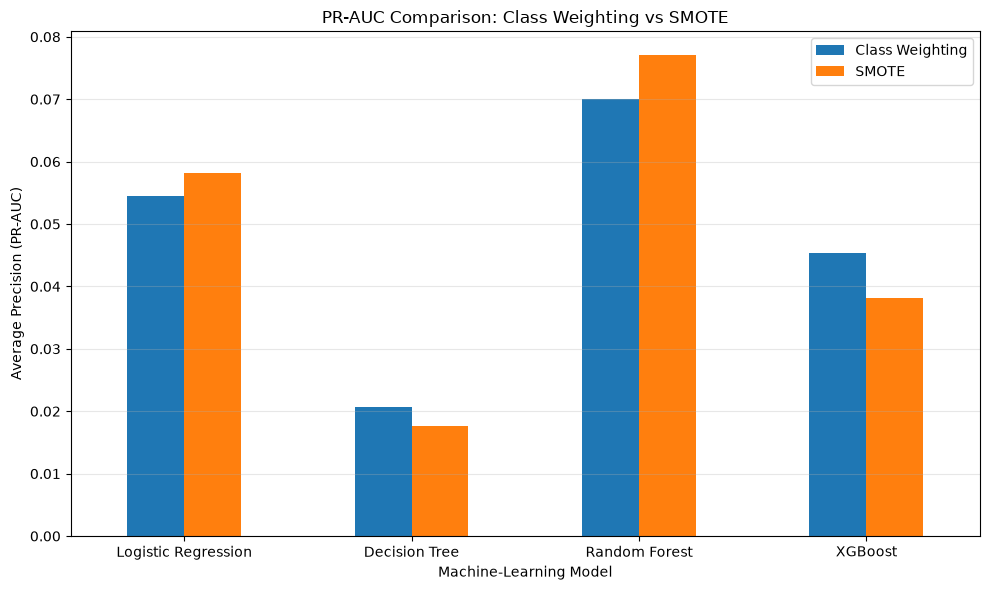

In [33]:
# Visual comparison of PR-AUC:
# Class Weighting vs SMOTE

plot_data = imbalance_comparison[
    ["Model", "Weighted_PR_AUC", "SMOTE_PR_AUC"]
].set_index("Model")

ax = plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("PR-AUC Comparison: Class Weighting vs SMOTE")
plt.xlabel("Machine-Learning Model")
plt.ylabel("Average Precision (PR-AUC)")
plt.xticks(rotation=0)
plt.legend(["Class Weighting", "SMOTE"])
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### PR-AUC Comparison of Imbalance-Handling Strategies

The figure compares Average Precision (PR-AUC) for class-weighted and SMOTE-based versions of the four classification algorithms.

Random Forest achieved the strongest probability-ranking performance. Its PR-AUC increased from **7.01% with class weighting to 7.70% with SMOTE**, representing the highest mean PR-AUC observed among the current model configurations.

Logistic Regression also showed a modest improvement with SMOTE, increasing from **5.46% to 5.82%**.

In contrast, SMOTE reduced PR-AUC for both Decision Tree (**2.07% to 1.77%**) and XGBoost (**4.53% to 3.82%**), demonstrating that synthetic oversampling did not consistently improve model performance.

Importantly, PR-AUC should not be interpreted in isolation. Although Random Forest with SMOTE achieved the highest PR-AUC, its recall at the default classification threshold was only **1.82%**, compared with **10.61%** for the class-weighted Random Forest.

Therefore, the results suggest that the effect of imbalance handling depends on both the algorithm and the evaluation objective. Model selection will consider PR-AUC together with recall, precision, F1-score and later threshold-based evaluation rather than selecting the model from a single metric.

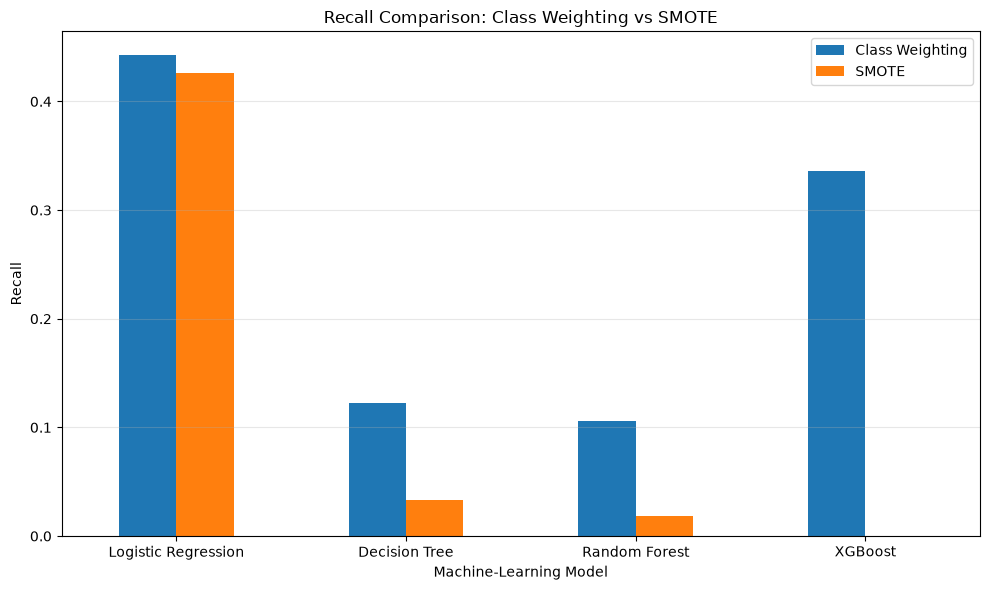

In [34]:
# Visual comparison of Recall:
# Class Weighting vs SMOTE

recall_plot_data = imbalance_comparison[
    ["Model", "Weighted_Recall", "SMOTE_Recall"]
].set_index("Model")

ax = recall_plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Recall Comparison: Class Weighting vs SMOTE")
plt.xlabel("Machine-Learning Model")
plt.ylabel("Recall")
plt.xticks(rotation=0)
plt.legend(["Class Weighting", "SMOTE"])
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Recall Comparison of Imbalance-Handling Strategies

The recall comparison shows substantial differences in the ability of the models to identify truly adverse food samples.

Class-weighted Logistic Regression achieved the highest mean recall at **44.24%**, followed closely by Logistic Regression with SMOTE at **42.58%**. This means that, during cross-validation, these models identified approximately four out of every ten adverse samples.

Weighted XGBoost achieved the next-highest recall at **33.64%**, indicating that class weighting allowed XGBoost to detect approximately one-third of the adverse samples.

In contrast, SMOTE substantially reduced recall for Decision Tree, Random Forest and XGBoost. Random Forest recall decreased from **10.61% to 1.82%**, while XGBoost decreased from **33.64% to 0.00%**.

These results are particularly important in the food-safety context because a false negative represents an adverse sample that the model fails to identify as elevated risk.

The comparison therefore indicates that class weighting currently provides a more reliable imbalance-handling strategy for preserving adverse-class detection across most of the evaluated algorithms.

However, recall must be considered together with precision and PR-AUC. A model could obtain high recall by flagging many samples as adverse, potentially creating an excessive number of false-positive alerts. Final model selection will therefore consider the trade-off between detecting adverse samples and maintaining useful precision.

## Hyperparameter Tuning

Following the initial model and imbalance-handling comparisons, selected models will now be optimized using stratified cross-validation.

Hyperparameter tuning will be performed exclusively on the training data. The test set will remain untouched until the final selected model has been determined.

Because the target class is extremely imbalanced, Average Precision (PR-AUC) will be used as the primary optimization metric. Recall, precision and F1-score will subsequently be examined to ensure that improved probability-ranking performance also provides practically useful adverse-sample detection.

In [35]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter values to test for Logistic Regression
logistic_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100]
}

print("Logistic Regression tuning grid created.")
print(logistic_param_grid)

Logistic Regression tuning grid created.
{'classifier__C': [0.01, 0.1, 1, 10, 100]}


In [36]:
# Create Logistic Regression GridSearchCV

logistic_grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

print("Logistic Regression GridSearchCV created successfully.")

Logistic Regression GridSearchCV created successfully.


In [37]:
# Run Logistic Regression hyperparameter tuning

logistic_grid_search.fit(X_train, y_train)

print("Logistic Regression tuning completed.")

print("\nBest parameter:")
print(logistic_grid_search.best_params_)

print("\nBest cross-validated PR-AUC:")
print(f"{logistic_grid_search.best_score_:.4f}")

Logistic Regression tuning completed.

Best parameter:
{'classifier__C': 1}

Best cross-validated PR-AUC:
0.0546


### Logistic Regression Hyperparameter-Tuning Result

GridSearchCV was used to evaluate five regularization strengths for the class-weighted Logistic Regression model using five-fold Stratified Cross-Validation and Average Precision (PR-AUC) as the optimization metric.

The best hyperparameter was:

- **C = 1**

The corresponding mean cross-validated PR-AUC was **5.46%**.

This is identical to the PR-AUC obtained by the original class-weighted Logistic Regression model. Therefore, tuning the regularization strength did not improve its probability-ranking performance.

The result indicates that the original regularization setting of C = 1 was already the strongest among the tested values. Importantly, the absence of improvement is still informative because the hyperparameter choice was evaluated systematically rather than assumed.

The Logistic Regression model will therefore retain C = 1 for subsequent model comparison and evaluation.

In [38]:
# Hyperparameter grid for Random Forest

rf_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5],
    "classifier__max_features": ["sqrt", "log2"]
}

print("Random Forest tuning grid created.")
print(rf_param_grid)

Random Forest tuning grid created.
{'classifier__n_estimators': [100, 200, 300], 'classifier__max_depth': [None, 10, 20], 'classifier__min_samples_leaf': [1, 2, 5], 'classifier__max_features': ['sqrt', 'log2']}


In [39]:
# Create Random Forest GridSearchCV

rf_grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=rf_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

print("Random Forest GridSearchCV created successfully.")

Random Forest GridSearchCV created successfully.


In [40]:
# Run Random Forest hyperparameter tuning

rf_grid_search.fit(X_train, y_train)

print("Random Forest tuning completed.")

print("\nBest parameters:")
print(rf_grid_search.best_params_)

print("\nBest cross-validated PR-AUC:")
print(f"{rf_grid_search.best_score_:.4f}")

Random Forest tuning completed.

Best parameters:
{'classifier__max_depth': None, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 200}

Best cross-validated PR-AUC:
0.1032


### Random Forest Hyperparameter-Tuning Result

GridSearchCV evaluated 54 Random Forest hyperparameter combinations using five-fold Stratified Cross-Validation, with Average Precision (PR-AUC) as the optimization metric.

The best configuration was:

- **Number of trees (n_estimators): 200**
- **Maximum depth (max_depth): None**
- **Minimum samples per leaf (min_samples_leaf): 2**
- **Maximum features per split (max_features): log2**

The tuned Random Forest achieved a mean cross-validated PR-AUC of **10.32%**, compared with **7.01%** for the initial class-weighted Random Forest.

This represents an absolute improvement of **3.31 percentage points** and an approximate **47% relative increase in PR-AUC**.

The improvement indicates that Random Forest performance was sensitive to its hyperparameter configuration and that systematic tuning substantially improved its ability to rank adverse samples above non-adverse samples.

The tuned Random Forest currently provides the strongest cross-validated PR-AUC observed in the modelling analysis. However, it will not yet be selected as the final model because adverse-class recall, precision, F1-score and threshold behaviour must also be considered before final model selection.

In [41]:
# Retrieve the best tuned Random Forest pipeline
best_rf_pipeline = rf_grid_search.best_estimator_

# Evaluate the tuned Random Forest across all CV metrics
tuned_rf_cv_results = cross_validate(
    best_rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Tuned Random Forest cross-validation completed.")

print("\nMean CV scores:")
print(f"Precision:         {tuned_rf_cv_results['test_precision'].mean():.4f}")
print(f"Recall:            {tuned_rf_cv_results['test_recall'].mean():.4f}")
print(f"F1-score:          {tuned_rf_cv_results['test_f1'].mean():.4f}")
print(f"Average Precision: {tuned_rf_cv_results['test_average_precision'].mean():.4f}")
print(f"ROC-AUC:           {tuned_rf_cv_results['test_roc_auc'].mean():.4f}")

Tuned Random Forest cross-validation completed.

Mean CV scores:
Precision:         0.0430
Recall:            0.4212
F1-score:          0.0778
Average Precision: 0.1032
ROC-AUC:           0.7998


### Tuned Random Forest — Cross-Validated Performance

The optimized Random Forest was subsequently evaluated using the same five-fold Stratified Cross-Validation procedure across all primary classification metrics.

Compared with the initial class-weighted Random Forest, tuning produced substantial improvements in several important measures:

- **Recall:** increased from 10.61% to **42.12%**
- **Average Precision (PR-AUC):** increased from 7.01% to **10.32%**
- **ROC-AUC:** increased from 75.48% to **79.98%**

However, precision decreased from 9.38% to **4.30%**, while F1-score decreased from 9.93% to **7.78%**.

The large increase in recall is particularly relevant to the food-safety screening objective. The tuned model identified approximately four out of every ten adverse samples during cross-validation, compared with approximately one out of ten for the initial Random Forest.

At the same time, the reduction in precision indicates that the improved adverse-sample detection is accompanied by a larger proportion of false-positive alerts.

The tuned Random Forest therefore represents a meaningful improvement in risk-screening capability rather than an improvement across every classification metric.

Importantly, its recall of **42.12%** is now close to the **44.24%** achieved by class-weighted Logistic Regression, while its PR-AUC of **10.32%** is substantially higher than Logistic Regression's **5.46%**.

This makes the tuned Random Forest a strong candidate for final model selection. Nevertheless, additional model tuning and threshold evaluation will be completed before the final model is selected and evaluated on the untouched test set.

In [42]:
# Hyperparameter grid for XGBoost

xgb_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [2, 3, 5],
    "classifier__learning_rate": [0.03, 0.1, 0.2]
}

print("XGBoost tuning grid created.")
print(xgb_param_grid)

XGBoost tuning grid created.
{'classifier__n_estimators': [100, 200, 300], 'classifier__max_depth': [2, 3, 5], 'classifier__learning_rate': [0.03, 0.1, 0.2]}


In [43]:
# Create XGBoost GridSearchCV

xgb_grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

print("XGBoost GridSearchCV created successfully.")

XGBoost GridSearchCV created successfully.


In [44]:
# Run XGBoost hyperparameter tuning

xgb_grid_search.fit(X_train, y_train)

print("XGBoost tuning completed.")

print("\nBest parameters:")
print(xgb_grid_search.best_params_)

print("\nBest cross-validated PR-AUC:")
print(f"{xgb_grid_search.best_score_:.4f}")

XGBoost tuning completed.

Best parameters:
{'classifier__learning_rate': 0.2, 'classifier__max_depth': 5, 'classifier__n_estimators': 300}

Best cross-validated PR-AUC:
0.0642


### XGBoost Hyperparameter-Tuning Result

GridSearchCV evaluated 27 XGBoost hyperparameter combinations using five-fold Stratified Cross-Validation, with Average Precision (PR-AUC) as the optimization metric.

The best configuration was:

- **Learning rate: 0.20**
- **Maximum tree depth: 5**
- **Number of estimators: 300**

The tuned XGBoost model achieved a mean cross-validated PR-AUC of **6.42%**, compared with **4.53%** for the initial class-weighted XGBoost model.

This represents an absolute improvement of **1.89 percentage points** and an approximate **41.7% relative increase in PR-AUC**.

The result demonstrates that XGBoost benefited meaningfully from hyperparameter optimization. However, its optimized PR-AUC remains below the **10.32%** achieved by the tuned Random Forest.

PR-AUC alone is not sufficient for final model selection. The tuned XGBoost model will therefore also be evaluated for recall, precision, F1-score and ROC-AUC before comparison with the other candidate models.

In [45]:
# Retrieve the best tuned XGBoost pipeline
best_xgb_pipeline = xgb_grid_search.best_estimator_

# Evaluate tuned XGBoost across all CV metrics
tuned_xgb_cv_results = cross_validate(
    best_xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Tuned XGBoost cross-validation completed.")

print("\nMean CV scores:")
print(f"Precision:         {tuned_xgb_cv_results['test_precision'].mean():.4f}")
print(f"Recall:            {tuned_xgb_cv_results['test_recall'].mean():.4f}")
print(f"F1-score:          {tuned_xgb_cv_results['test_f1'].mean():.4f}")
print(f"Average Precision: {tuned_xgb_cv_results['test_average_precision'].mean():.4f}")
print(f"ROC-AUC:           {tuned_xgb_cv_results['test_roc_auc'].mean():.4f}")

Tuned XGBoost cross-validation completed.

Mean CV scores:
Precision:         0.0679
Recall:            0.1439
F1-score:          0.0922
Average Precision: 0.0642
ROC-AUC:           0.7557


### Tuned XGBoost — Cross-Validated Performance

The tuned XGBoost model was evaluated using the same five-fold Stratified Cross-Validation procedure across all primary classification metrics.

Compared with the initial class-weighted XGBoost model, hyperparameter tuning produced the following changes:

- **Precision:** increased from 3.25% to **6.79%**
- **Recall:** decreased from 33.64% to **14.39%**
- **F1-score:** increased from 5.92% to **9.22%**
- **Average Precision (PR-AUC):** increased from 4.53% to **6.42%**
- **ROC-AUC:** increased from 73.39% to **75.57%**

The tuned model therefore achieved better precision, F1-score and probability-ranking performance, but this improvement was accompanied by a substantial reduction in adverse-class recall.

This trade-off is particularly important for the food-safety screening objective, where failing to identify genuinely adverse samples may carry a greater practical cost than generating additional false-positive alerts.

Compared with the tuned Random Forest, tuned XGBoost currently provides lower recall (14.39% vs 42.12%) and lower PR-AUC (6.42% vs 10.32%).

Therefore, the tuned Random Forest currently appears to provide the stronger balance between adverse-sample detection and probability-ranking performance. Final model selection will nevertheless consider the complete cross-validated comparison and subsequent threshold analysis.

In [46]:
# Compare key cross-validated model performances

tuned_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Tuned Random Forest",
        "Tuned XGBoost"
    ],
    "Precision": [
        logistic_cv_results["test_precision"].mean(),
        tuned_rf_cv_results["test_precision"].mean(),
        tuned_xgb_cv_results["test_precision"].mean()
    ],
    "Recall": [
        logistic_cv_results["test_recall"].mean(),
        tuned_rf_cv_results["test_recall"].mean(),
        tuned_xgb_cv_results["test_recall"].mean()
    ],
    "F1": [
        logistic_cv_results["test_f1"].mean(),
        tuned_rf_cv_results["test_f1"].mean(),
        tuned_xgb_cv_results["test_f1"].mean()
    ],
    "PR_AUC": [
        logistic_cv_results["test_average_precision"].mean(),
        tuned_rf_cv_results["test_average_precision"].mean(),
        tuned_xgb_cv_results["test_average_precision"].mean()
    ],
    "ROC_AUC": [
        logistic_cv_results["test_roc_auc"].mean(),
        tuned_rf_cv_results["test_roc_auc"].mean(),
        tuned_xgb_cv_results["test_roc_auc"].mean()
    ]
})

tuned_model_comparison.round(4)

,Model,Precision,Recall,F1,PR_AUC,ROC_AUC
0,Logistic Regression,0.0380,0.4424,0.0699,0.0546,0.7781
1,Tuned Random Forest,0.0430,0.4212,0.0778,0.1032,0.7998
2,Tuned XGBoost,0.0679,0.1439,0.0922,0.0642,0.7557


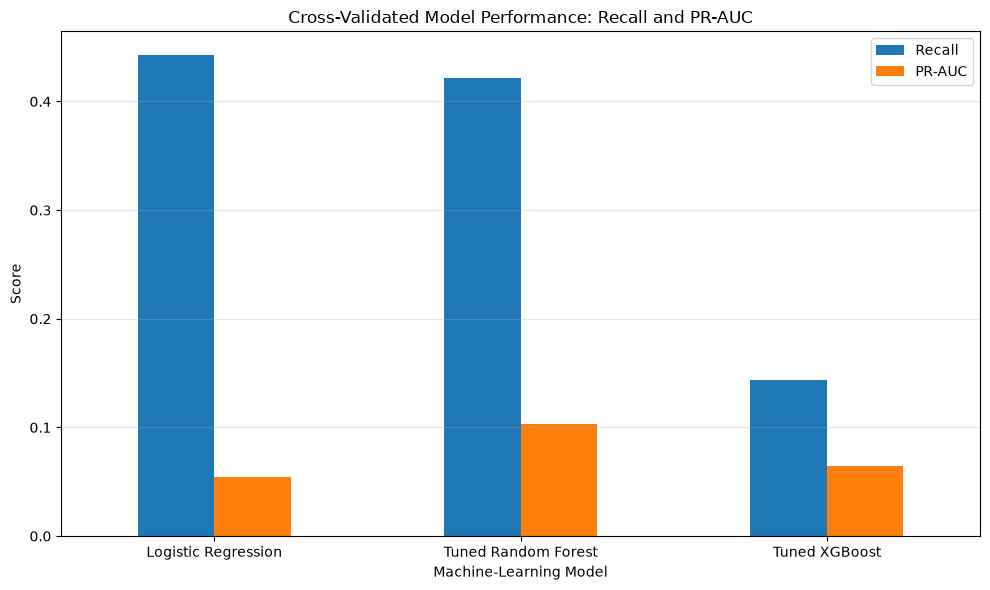

In [47]:
# Visual comparison of the main tuned candidate models

comparison_plot = tuned_model_comparison[
    ["Model", "Recall", "PR_AUC"]
].set_index("Model")

ax = comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Cross-Validated Model Performance: Recall and PR-AUC")
plt.xlabel("Machine-Learning Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(["Recall", "PR-AUC"])
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### Cross-Validated Candidate-Model Comparison

The cross-validated comparison reveals an important trade-off between adverse-sample detection and probability-ranking performance.

**Logistic Regression** achieved the highest recall at **44.24%**, indicating the strongest adverse-sample detection at the default classification threshold. However, its PR-AUC was comparatively lower at **5.46%**.

The **tuned Random Forest** achieved a very similar recall of **42.12%**, while producing the highest PR-AUC at **10.32%**. This indicates substantially stronger ability to rank genuinely adverse samples above non-adverse samples while retaining a level of adverse-sample detection close to Logistic Regression.

The **tuned XGBoost** achieved a PR-AUC of **6.42%**, but its recall of **14.39%** was considerably lower than the other two candidate models.

Overall, the tuned Random Forest currently provides the strongest combination of recall and PR-AUC among the evaluated candidates. However, the default classification threshold may not represent the most appropriate operating point for a food-safety risk-screening application.

The next stage therefore examines model probabilities and the precision–recall trade-off across alternative classification thresholds before the final model and decision threshold are selected.

In [48]:
# Generate out-of-fold probabilities using the tuned Random Forest
rf_oof_probabilities = cross_val_predict(
    best_rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("Out-of-fold probabilities generated successfully.")
print(f"Number of probabilities: {len(rf_oof_probabilities)}")
print(f"Minimum probability: {rf_oof_probabilities.min():.4f}")
print(f"Maximum probability: {rf_oof_probabilities.max():.4f}")

Out-of-fold probabilities generated successfully.
Number of probabilities: 6865
Minimum probability: 0.0373
Maximum probability: 0.8541


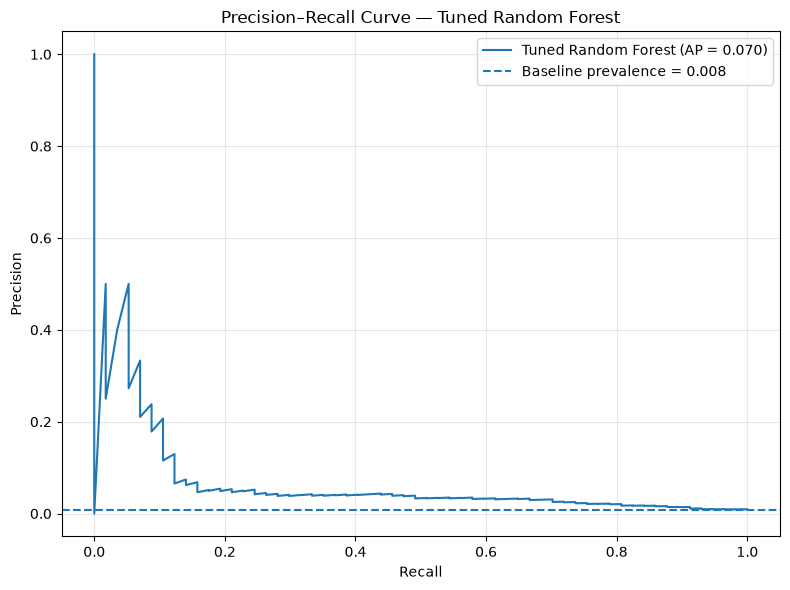

Out-of-fold PR-AUC: 0.0697
Adverse-class prevalence: 0.0083


In [49]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate precision, recall and thresholds
rf_precision_curve, rf_recall_curve, rf_thresholds = precision_recall_curve(
    y_train,
    rf_oof_probabilities
)

# Calculate PR-AUC / Average Precision
rf_oof_ap = average_precision_score(
    y_train,
    rf_oof_probabilities
)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))

plt.plot(
    rf_recall_curve,
    rf_precision_curve,
    label=f"Tuned Random Forest (AP = {rf_oof_ap:.3f})"
)

# Baseline = prevalence of adverse samples in training data
baseline = y_train.mean()
plt.axhline(
    y=baseline,
    linestyle="--",
    label=f"Baseline prevalence = {baseline:.3f}"
)

plt.title("Precision–Recall Curve — Tuned Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

print(f"Out-of-fold PR-AUC: {rf_oof_ap:.4f}")
print(f"Adverse-class prevalence: {baseline:.4f}")


### Precision–Recall Curve Interpretation

The Precision–Recall curve evaluates the tuned Random Forest across alternative classification thresholds using out-of-fold predictions from the training data.

The pooled out-of-fold Average Precision (PR-AUC) was approximately **6.97%**, compared with an adverse-class prevalence baseline of approximately **0.83%**. The model therefore demonstrates meaningful ranking ability above the prevalence baseline, although the precision–recall trade-off remains challenging because adverse samples are extremely rare.

The curve shows that higher precision can be achieved when the model flags only a small number of the highest-risk samples. As recall increases, precision decreases because progressively more non-adverse samples must also be flagged in order to identify additional adverse cases.

The pooled out-of-fold PR-AUC differs from the **10.32% mean cross-validated PR-AUC** reported during GridSearchCV. The GridSearchCV value represents the mean Average Precision calculated separately across the five validation folds, whereas the present value is calculated once after pooling all out-of-fold predictions. With only 57 adverse samples in the training data, variation between folds can produce a noticeable difference between these two summaries.

The Precision–Recall curve nevertheless confirms that the model contains predictive ranking information beyond the adverse-class prevalence baseline. The next analysis examines how changing the classification threshold affects recall and precision in order to identify a more appropriate operating point for food-safety risk screening.

In [50]:
# Evaluate precision and recall across classification thresholds

threshold_values = np.arange(0.05, 0.81, 0.05)

threshold_results = []

for threshold in threshold_values:
    predictions = (rf_oof_probabilities >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_train, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_train, predictions, zero_division=0
        ),
        "F1": f1_score(
            y_train, predictions, zero_division=0
        ),
        "Samples_Flagged": predictions.sum()
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.round(4)

,Threshold,Precision,Recall,F1,Samples_Flagged
0,0.05,0.0083,1.0000,0.0165,6853
1,0.10,0.0088,1.0000,0.0174,6505
2,0.15,0.0098,0.9298,0.0194,5395
3,0.20,0.0125,0.9123,0.0247,4161
4,0.25,0.0161,0.8596,0.0317,3038
5,0.30,0.0213,0.7719,0.0414,2069
6,0.35,0.0268,0.7018,0.0516,1492
7,0.40,0.0326,0.6140,0.0620,1072
8,0.45,0.0350,0.4912,0.0653,800
9,0.50,0.0420,0.4211,0.0764,571


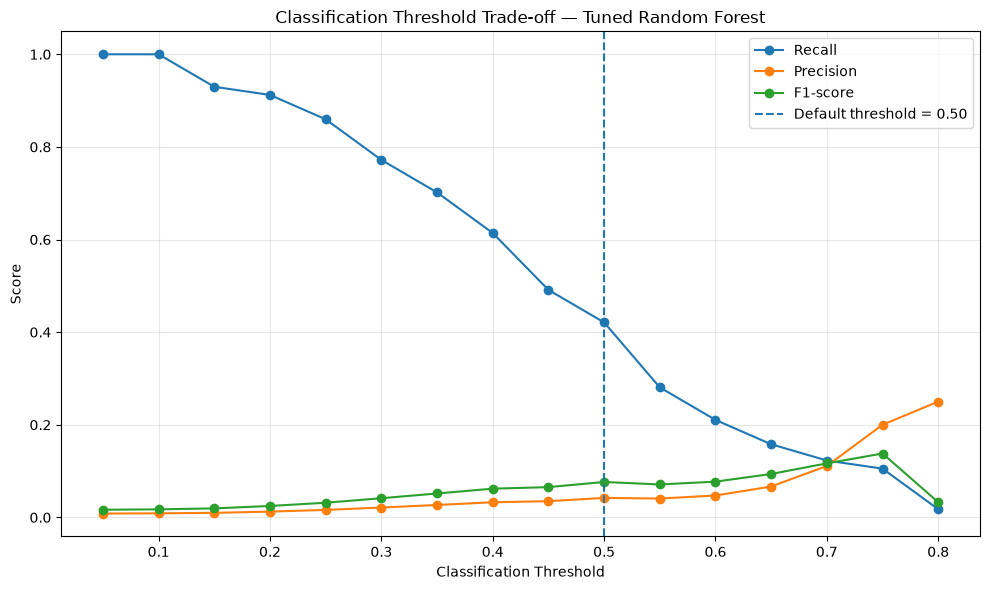

In [51]:
# Plot classification-threshold trade-offs

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    marker="o",
    label="F1-score"
)

plt.axvline(
    x=0.50,
    linestyle="--",
    label="Default threshold = 0.50"
)

plt.title("Classification Threshold Trade-off — Tuned Random Forest")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Classification-Threshold Trade-off

The threshold analysis demonstrates that the default probability threshold of **0.50** is not the only possible operating point for the tuned Random Forest.

At the default threshold of 0.50, the model achieved approximately **42.11% recall**, meaning that approximately four out of every ten adverse samples were identified.

Lowering the threshold substantially increased adverse-sample detection:

- At **0.40**, recall increased to **61.40%**, with 1,072 samples flagged.
- At **0.35**, recall increased to **70.18%**, with 1,492 samples flagged.
- At **0.30**, recall increased to **77.19%**, but 2,069 samples were flagged.

This improvement in recall is accompanied by lower precision and a larger number of false-positive alerts. Therefore, simply selecting the threshold with the highest recall would not provide an efficient risk-prioritization system.

Conversely, higher thresholds improve precision but identify a much smaller proportion of genuinely adverse samples. For example, at a threshold of 0.75, precision increased to 20.00%, but recall decreased to only 10.53%.

The results therefore demonstrate a clear operational trade-off between detecting more potentially adverse samples and limiting the number of samples flagged for additional attention.

For a food-safety risk-screening application, an intermediate threshold may provide a more useful operating point than either extreme. The final threshold should therefore consider recall, false-positive burden and the proportion of samples requiring additional inspection rather than relying on F1-score alone.

In [52]:
# Calculate the operational screening burden at each threshold

threshold_results["Flagged_Percentage"] = (
    threshold_results["Samples_Flagged"] / len(y_train) * 100
)

screening_summary = threshold_results[
    [
        "Threshold",
        "Recall",
        "Precision",
        "Samples_Flagged",
        "Flagged_Percentage"
    ]
].copy()

screening_summary["Adverse_Captured_Percentage"] = (
    screening_summary["Recall"] * 100
)

screening_summary[
    (screening_summary["Threshold"] >= 0.30) &
    (screening_summary["Threshold"] <= 0.50)
].round(2)

,Threshold,Recall,Precision,Samples_Flagged,Flagged_Percentage,Adverse_Captured_Percentage
5,0.30,0.77,0.02,2069,30.14,77.19
6,0.35,0.70,0.03,1492,21.73,70.18
7,0.40,0.61,0.03,1072,15.62,61.40
8,0.45,0.49,0.04,800,11.65,49.12
9,0.50,0.42,0.04,571,8.32,42.11


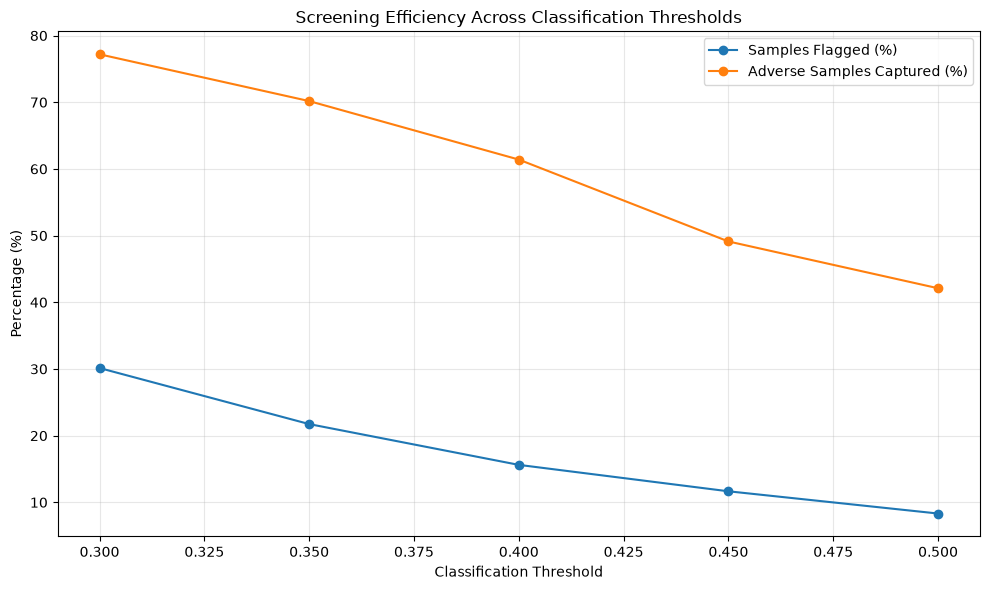

In [53]:
# Visualize screening burden versus adverse-sample capture

screening_plot = screening_summary[
    (screening_summary["Threshold"] >= 0.30) &
    (screening_summary["Threshold"] <= 0.50)
].copy()

plt.figure(figsize=(10, 6))

plt.plot(
    screening_plot["Threshold"],
    screening_plot["Flagged_Percentage"],
    marker="o",
    label="Samples Flagged (%)"
)

plt.plot(
    screening_plot["Threshold"],
    screening_plot["Adverse_Captured_Percentage"],
    marker="o",
    label="Adverse Samples Captured (%)"
)

plt.title("Screening Efficiency Across Classification Thresholds")
plt.xlabel("Classification Threshold")
plt.ylabel("Percentage (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Screening-Efficiency Interpretation

The screening-efficiency analysis translates the model's classification performance into a practical food-safety prioritization scenario.

At a classification threshold of **0.40**, approximately **15.62% of all samples** would be flagged for additional attention, while this flagged group would capture approximately **61.40% of the genuinely adverse samples**.

Lowering the threshold to 0.35 increases adverse-sample capture to **70.18%**, but also increases the proportion of samples requiring additional attention to **21.73%**.

At the default threshold of 0.50, only **8.32% of samples** are flagged, but adverse-sample capture falls to **42.11%**.

These results demonstrate that the model can concentrate a substantial proportion of adverse findings within a considerably smaller subset of the total sample population.

For a risk-prioritization application, a threshold of **0.40** provides a defensible candidate operating point because it captures more than 60% of adverse samples while directing additional attention to approximately 16% of samples.

The 0.40 threshold will therefore be carried forward as the candidate operating threshold. Its classification behaviour will next be examined through a confusion matrix before final evaluation on the untouched test set.

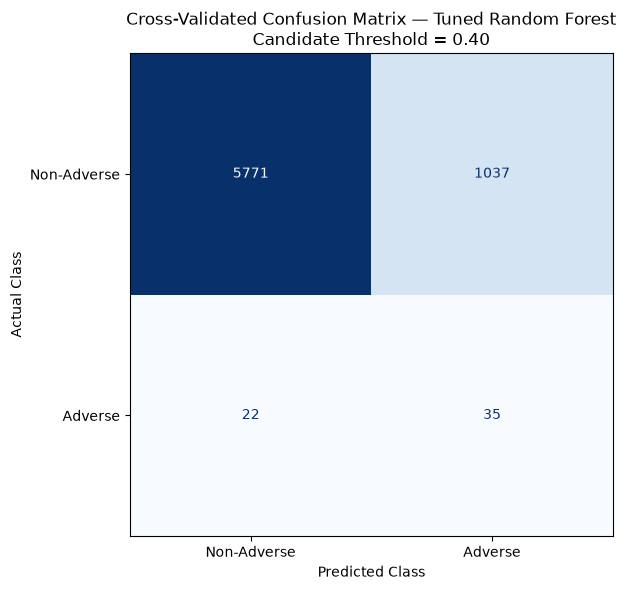

True Negatives (TN):  5771
False Positives (FP): 1037
False Negatives (FN): 22
True Positives (TP):  35


In [54]:
# Create out-of-fold predictions at the candidate threshold

candidate_threshold = 0.40

rf_oof_predictions_040 = (
    rf_oof_probabilities >= candidate_threshold
).astype(int)

# Calculate confusion matrix
rf_cm_040 = confusion_matrix(
    y_train,
    rf_oof_predictions_040
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm_040,
    display_labels=["Non-Adverse", "Adverse"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title(
    "Cross-Validated Confusion Matrix — Tuned Random Forest\n"
    "Candidate Threshold = 0.40"
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()

plt.show()

# Print the four components
tn, fp, fn, tp = rf_cm_040.ravel()

print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")

### Cross-Validated Confusion-Matrix Interpretation

At the candidate classification threshold of **0.40**, the tuned Random Forest produced the following out-of-fold classification results:

- **5,771 True Negatives (TN):** non-adverse samples correctly remained unflagged.
- **1,037 False Positives (FP):** non-adverse samples were flagged as higher risk.
- **22 False Negatives (FN):** adverse samples were not identified by the model.
- **35 True Positives (TP):** adverse samples were correctly identified as higher risk.

Of the 57 adverse samples in the training data, the model identified **35**, corresponding to a recall of approximately **61.40%**.

Overall, 1,072 of the 6,865 samples were flagged, representing approximately **15.62% of the sample population**.

The confusion matrix therefore illustrates the intended role of the model as a **risk-prioritization tool rather than an automated regulatory decision system**. At the candidate threshold, the model concentrates approximately 61% of observed adverse cases within approximately 16% of the samples.

The principal cost of this increased sensitivity is the relatively large number of false-positive alerts. However, in a screening context, these false positives represent samples receiving additional attention rather than samples being automatically classified as regulatory failures.

The remaining 22 false negatives also demonstrate that the model cannot replace laboratory analysis or official food-safety assessment. Instead, its potential value lies in supporting risk-based prioritization of inspection or analytical resources.

## Final Model Selection

Based exclusively on the training data and cross-validation results, the **tuned Random Forest** was selected as the final candidate model.

The tuned Random Forest achieved:

- **Mean cross-validated PR-AUC: 10.32%**
- **Mean cross-validated ROC-AUC: 79.98%**
- **Recall at the default threshold: 42.12%**

It provided substantially stronger PR-AUC than Logistic Regression while maintaining a similar level of recall at the default threshold.

Threshold analysis using out-of-fold training predictions further showed that a probability threshold of **0.40** provided a practically relevant screening trade-off.

At this threshold:

- **61.40% of adverse samples were identified**
- **15.62% of all samples were flagged for additional attention**
- **35 of 57 adverse samples were detected**
- **22 adverse samples were missed**

The final modelling configuration is therefore:

**Model:** Tuned Random Forest  
**Classification threshold:** 0.40

Both the model and classification threshold were selected without using the test-set outcomes.

The untouched test set will now be used once for final performance evaluation. Test-set results will be treated as an estimate of generalization performance and will not be used to retune the model or alter the selected threshold.

In [55]:
# Fit the locked final model on the complete training dataset

final_rf_model = best_rf_pipeline

final_rf_model.fit(X_train, y_train)

print("Final tuned Random Forest fitted on the complete training set.")
print(f"Selected classification threshold: {candidate_threshold:.2f}")

Final tuned Random Forest fitted on the complete training set.
Selected classification threshold: 0.40


In [56]:
# Generate probabilities on the untouched test set

final_test_probabilities = final_rf_model.predict_proba(
    X_test
)[:, 1]

# Apply the pre-selected threshold of 0.40
final_test_predictions = (
    final_test_probabilities >= candidate_threshold
).astype(int)

print("Final test-set predictions generated.")
print(f"Test samples: {len(y_test)}")
print(f"Actual adverse samples: {y_test.sum()}")
print(f"Samples predicted as higher risk: {final_test_predictions.sum()}")

Final test-set predictions generated.
Test samples: 1717
Actual adverse samples: 14
Samples predicted as higher risk: 302


In [57]:
# Calculate final test-set performance metrics

final_precision = precision_score(
    y_test,
    final_test_predictions,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_test_predictions,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_test_predictions,
    zero_division=0
)

final_pr_auc = average_precision_score(
    y_test,
    final_test_probabilities
)

final_roc_auc = roc_auc_score(
    y_test,
    final_test_probabilities
)

final_cm = confusion_matrix(
    y_test,
    final_test_predictions
)

tn, fp, fn, tp = final_cm.ravel()

print("Final Test-Set Performance")
print("--------------------------")
print(f"Precision:  {final_precision:.4f}")
print(f"Recall:     {final_recall:.4f}")
print(f"F1-score:   {final_f1:.4f}")
print(f"PR-AUC:     {final_pr_auc:.4f}")
print(f"ROC-AUC:    {final_roc_auc:.4f}")

print("\nConfusion Matrix Components")
print("---------------------------")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")

Final Test-Set Performance
--------------------------
Precision:  0.0298
Recall:     0.6429
F1-score:   0.0570
PR-AUC:     0.1562
ROC-AUC:    0.8211

Confusion Matrix Components
---------------------------
True Negatives (TN):  1410
False Positives (FP): 293
False Negatives (FN): 5
True Positives (TP):  9


### Final Untouched Test-Set Evaluation

The locked tuned Random Forest and the pre-selected classification threshold of **0.40** were evaluated once on the previously untouched test set.

The final model achieved:

- **Precision: 2.98%**
- **Recall: 64.29%**
- **F1-score: 5.70%**
- **PR-AUC: 15.62%**
- **ROC-AUC: 82.11%**

The confusion-matrix components were:

- **1,410 True Negatives**
- **293 False Positives**
- **5 False Negatives**
- **9 True Positives**

Of the 14 genuinely adverse samples in the test set, the model successfully identified **9**, corresponding to a recall of **64.29%**.

The model flagged 302 of the 1,717 test samples, representing approximately **17.59% of the test population**. This higher-risk group contained 9 of the 14 observed adverse samples.

The final test results therefore support the model's potential use as a **risk-prioritization or screening tool**. The model was able to concentrate a majority of the observed adverse cases within a substantially smaller subset of the overall sample population.

However, precision remained low at **2.98%**, indicating that most flagged samples were ultimately non-adverse. The model should therefore not be interpreted as an automated regulatory decision system. Its more appropriate role is to support prioritization of samples for additional inspection or analytical attention.

The test set contained only **14 adverse samples**, meaning that individual cases have a substantial effect on recall and other adverse-class metrics. Consequently, the final performance estimates should be interpreted with appropriate caution and validated on additional data before operational deployment.

Importantly, neither the model configuration nor the 0.40 classification threshold was modified after examining the test-set results.

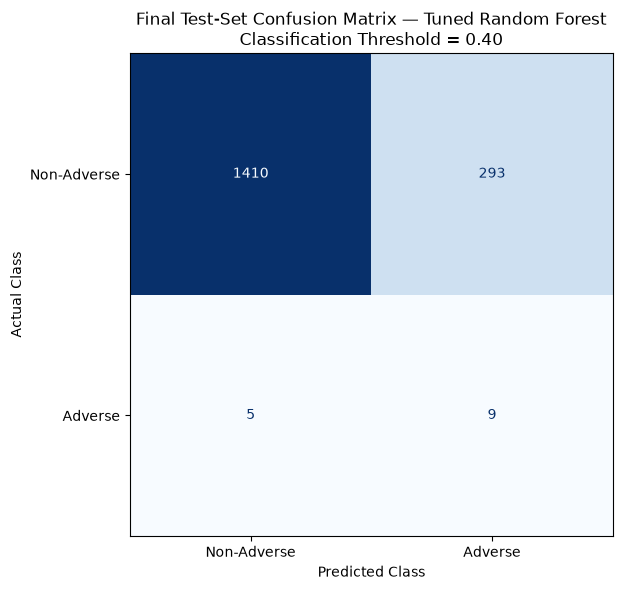

In [58]:
# Final test-set confusion matrix

final_cm = confusion_matrix(
    y_test,
    final_test_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["Non-Adverse", "Adverse"]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title(
    "Final Test-Set Confusion Matrix — Tuned Random Forest\n"
    "Classification Threshold = 0.40"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()

plt.show()

### Final Confusion-Matrix Interpretation

The final test-set confusion matrix shows the performance of the tuned Random Forest at the pre-selected classification threshold of **0.40**.

- **1,410 True Negatives (TN):** non-adverse samples were correctly left unflagged.
- **293 False Positives (FP):** non-adverse samples were flagged as higher risk.
- **5 False Negatives (FN):** adverse samples were missed by the model.
- **9 True Positives (TP):** adverse samples were correctly identified as higher risk.

The model therefore detected **9 of the 14 adverse samples**, corresponding to a recall of **64.29%**.

The relatively large number of false positives reflects the deliberate emphasis on detecting adverse samples in this highly imbalanced food-safety dataset. In the proposed screening context, a false positive means that a non-adverse sample would receive additional attention, whereas a false negative represents an adverse sample that the model failed to prioritize.

The model should therefore be interpreted as a **risk-prioritization tool rather than a replacement for laboratory testing or official regulatory assessment**.

Because the test set contains only 14 adverse samples, the confusion-matrix results should also be interpreted cautiously and validated using additional data before operational deployment.

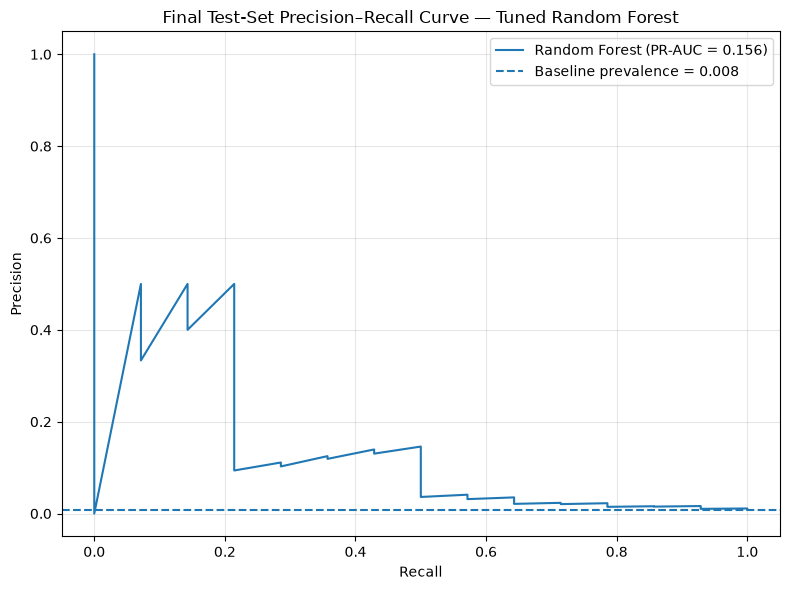

In [59]:
# Final test-set Precision-Recall curve

from sklearn.metrics import precision_recall_curve

test_precision_curve, test_recall_curve, _ = precision_recall_curve(
    y_test,
    final_test_probabilities
)

test_pr_auc = average_precision_score(
    y_test,
    final_test_probabilities
)

test_baseline = y_test.mean()

plt.figure(figsize=(8, 6))

plt.plot(
    test_recall_curve,
    test_precision_curve,
    label=f"Random Forest (PR-AUC = {test_pr_auc:.3f})"
)

plt.axhline(
    y=test_baseline,
    linestyle="--",
    label=f"Baseline prevalence = {test_baseline:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    "Final Test-Set Precision–Recall Curve — Tuned Random Forest"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Final Precision–Recall Curve Interpretation

The final Precision–Recall curve evaluates the tuned Random Forest across the full range of possible classification thresholds on the test set.

The model achieved a test-set **PR-AUC (Average Precision) of 15.62%**, compared with an adverse-class prevalence baseline of approximately **0.82%**.

This indicates that the model ranks adverse samples substantially better than would be expected from the underlying class prevalence alone.

The curve also illustrates the trade-off between precision and recall. Higher precision can be achieved when the model focuses on a relatively small number of high-risk samples, but precision decreases as the model attempts to identify a larger proportion of the adverse cases.

The irregular shape of the curve is expected because the test set contains only **14 adverse samples**. Each correctly or incorrectly ranked adverse sample therefore has a relatively large influence on the curve.

For this project, the Precision–Recall curve is particularly informative because the target is extremely imbalanced. It provides a more useful view of adverse-class detection performance than accuracy alone.

The final PR-AUC result supports the conclusion that the model contains meaningful risk-ranking information, while the small number of adverse test observations means that the exact performance estimate should be interpreted cautiously.

In [60]:
# Extract grouped feature importance from the final Random Forest

fitted_preprocessor = final_rf_model.named_steps["preprocessor"]
fitted_encoder = fitted_preprocessor.named_transformers_["categorical"]
fitted_rf = final_rf_model.named_steps["classifier"]

# Random Forest importance for every one-hot encoded column
encoded_importances = fitted_rf.feature_importances_

# Aggregate encoded columns back to their original predictor
grouped_importance = {}

start = 0

for feature, categories in zip(
    categorical_features,
    fitted_encoder.categories_
):
    end = start + len(categories)

    grouped_importance[feature] = (
        encoded_importances[start:end].sum()
    )

    start = end

feature_importance_df = (
    pd.DataFrame(
        grouped_importance.items(),
        columns=["Feature", "Importance"]
    )
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance_df

,Feature,Importance
0,MatrixT,0.277124
1,MatrixGrT,0.164820
2,Country_Feature,0.111213
3,Sampling_Month,0.111204
4,Packaging_Feature,0.106091
5,BetriebsartT,0.106063
6,Processing_Feature,0.086257
7,PnMgT,0.037228


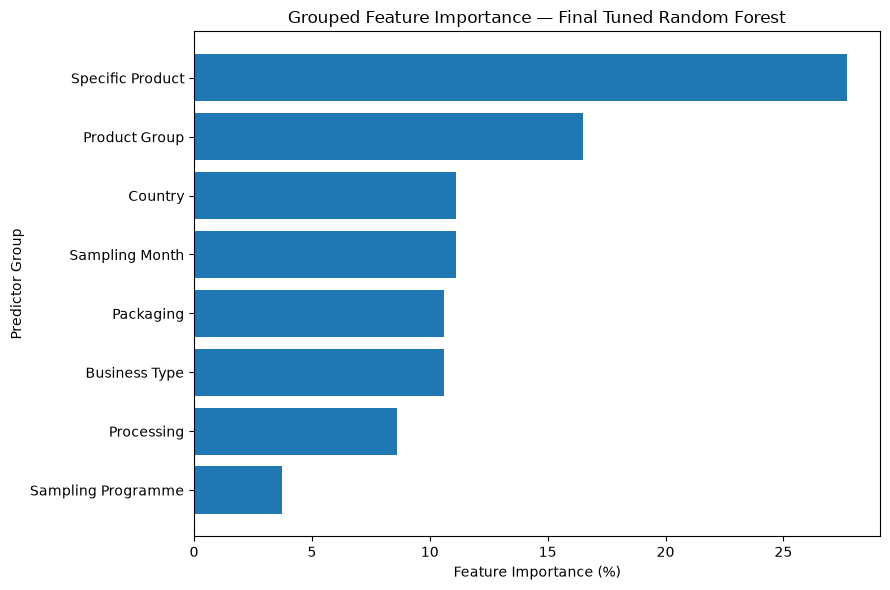

In [61]:
# Create presentation-friendly English feature labels

feature_label_map = {
    "MatrixT": "Specific Product",
    "MatrixGrT": "Product Group",
    "Country_Feature": "Country",
    "Sampling_Month": "Sampling Month",
    "Packaging_Feature": "Packaging",
    "BetriebsartT": "Business Type",
    "Processing_Feature": "Processing",
    "PnMgT": "Sampling Programme"
}

feature_importance_plot = feature_importance_df.copy()

feature_importance_plot["Feature"] = (
    feature_importance_plot["Feature"]
    .map(feature_label_map)
)

# Convert importance to percentage
feature_importance_plot["Importance_Percent"] = (
    feature_importance_plot["Importance"] * 100
)

# Sort for horizontal bar chart
feature_importance_plot = feature_importance_plot.sort_values(
    "Importance_Percent",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    feature_importance_plot["Feature"],
    feature_importance_plot["Importance_Percent"]
)

plt.xlabel("Feature Importance (%)")
plt.ylabel("Predictor Group")
plt.title(
    "Grouped Feature Importance — Final Tuned Random Forest"
)

plt.tight_layout()
plt.show()

### Feature-Importance Interpretation

The grouped feature-importance analysis indicates which predictor groups contributed most strongly to the final Random Forest's predictions.

The most important predictor was **Specific Product**, accounting for approximately **27.71%** of the model's total feature importance. This was followed by **Product Group** at approximately **16.48%**.

Other meaningful contributions came from:

- **Country: 11.12%**
- **Sampling Month: 11.12%**
- **Packaging: 10.61%**
- **Business Type: 10.61%**
- **Processing: 8.63%**
- **Sampling Programme: 3.72%**

The results suggest that information about the type of food product is particularly useful for distinguishing between samples with different levels of predicted adverse-finding risk. Country, sampling period, packaging, business type and processing characteristics also contribute to the model's risk ranking.

However, feature importance should not be interpreted as evidence of causation. A high importance value means that the Random Forest made substantial use of that predictor when generating predictions; it does not demonstrate that the predictor itself causes adverse food-safety findings.

In addition, **Specific Product** and **Product Group** are hierarchically related because each specific product belongs to a broader product group. Their importance values should therefore not be interpreted as completely independent effects.

Random Forest impurity-based feature importance can also favour predictors containing larger numbers of categories or potential splits. Consequently, the ranking is best interpreted as an indication of the model's predictive reliance on the available information rather than as a direct measure of real-world causal influence.

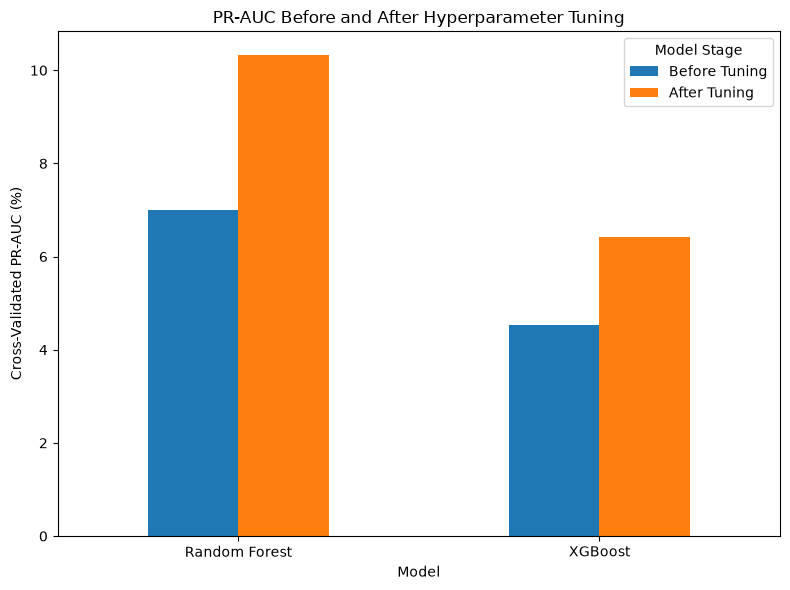

In [62]:
# Compare PR-AUC before and after hyperparameter tuning

tuning_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost"
    ],
    "Before Tuning": [
        0.0701,
        0.0453
    ],
    "After Tuning": [
        0.1032,
        0.0642
    ]
})

tuning_plot = tuning_comparison.set_index("Model") * 100

ax = tuning_plot.plot(
    kind="bar",
    figsize=(8, 6)
)

plt.ylabel("Cross-Validated PR-AUC (%)")
plt.xlabel("Model")
plt.title("PR-AUC Before and After Hyperparameter Tuning")
plt.xticks(rotation=0)
plt.legend(title="Model Stage")
plt.tight_layout()

plt.show()

### Effect of Hyperparameter Tuning

Hyperparameter tuning improved the cross-validated PR-AUC performance of both Random Forest and XGBoost.

For the **Random Forest**, mean cross-validated PR-AUC increased from **7.01% before tuning to 10.32% after tuning**. This represents an absolute improvement of **3.31 percentage points** and a relative improvement of approximately **47%**.

For **XGBoost**, mean cross-validated PR-AUC increased from **4.53% to 6.42%**, representing an absolute improvement of **1.89 percentage points** and a relative improvement of approximately **42%**.

The improvement was particularly important for the Random Forest because it ultimately achieved the strongest cross-validated PR-AUC among the candidate models.

These results demonstrate that hyperparameter optimization produced measurable improvements in the models' ability to rank adverse samples in this highly imbalanced classification problem.

However, tuning did not improve every evaluation metric simultaneously. Model selection therefore considered PR-AUC together with recall, precision, F1-score and the operational consequences of the selected classification threshold.

## Final Modelling Conclusion

The final tuned Random Forest was selected using training-data cross-validation and a pre-selected operating threshold of **0.40**. On the holdout test set, it achieved **64.29% recall**, **15.62% PR-AUC** and **82.11% ROC-AUC**, identifying **9 of 14 adverse samples** while flagging **302 of 1,717 samples** for additional attention.

The results support use of the model as a **risk-prioritization and screening aid**, not as an automated regulatory decision system. Low precision and the small number of adverse test cases remain important limitations, and further validation on additional data would be required before operational deployment.


## Research Question 2 — Which Sample and Monitoring Characteristics Are Associated with Adverse Findings?

The analysis indicates that adverse findings are associated with multiple sample and monitoring characteristics rather than with product category alone.

Exploratory analysis identified differences in adverse-finding rates across characteristics including **country, business type, sampling programme, processing, packaging and sampling period**.

Statistical testing provided some evidence that these relationships were not entirely random. For example, after grouping countries with small sample counts, the association between country and adverse findings produced a chi-square p-value of approximately **0.0149**. Business type also showed evidence of association with adverse findings, with a chi-square p-value of approximately **0.0019**.

However, several contingency tables contained relatively small expected cell counts. These statistical results should therefore be interpreted cautiously rather than treated as definitive evidence that a particular country or business type causes higher food-safety risk.

The machine-learning results provide additional evidence that these characteristics contain predictive information. In the final tuned Random Forest, grouped feature importance was approximately:

- **Specific Product: 27.71%**
- **Product Group: 16.48%**
- **Country: 11.12%**
- **Sampling Month: 11.12%**
- **Packaging: 10.61%**
- **Business Type: 10.61%**
- **Processing: 8.63%**
- **Sampling Programme: 3.72%**

This suggests that the model benefited from combining product characteristics with contextual information about where, when and under what conditions samples were collected.

The findings should not be interpreted causally. Feature importance measures how strongly the Random Forest used the available predictors for prediction; it does not demonstrate that these characteristics themselves cause adverse food-safety findings.

Overall, the results support a **multifactor risk-prioritization approach** in which product identity is considered together with contextual sampling and monitoring characteristics.

## Research Question 3 — Can Pre-Outcome Characteristics Predict Elevated Adverse-Finding Risk?

The machine-learning analysis indicates that characteristics available before the final analytical assessment contain useful information for identifying samples with elevated adverse-finding risk.

This prediction problem was particularly challenging because only approximately **0.83%** of the food samples were classified as adverse. A naive model predicting every sample as non-adverse could therefore achieve approximately **99.18% accuracy while detecting none of the adverse samples**. For this reason, model evaluation focused primarily on recall, precision, F1-score and Precision–Recall performance rather than accuracy alone.

Four classification approaches were investigated: **Logistic Regression, Decision Tree, Random Forest and XGBoost**. Class weighting and SMOTE were also compared as alternative approaches to handling the severe class imbalance.

Using stratified cross-validation and hyperparameter tuning, the **tuned Random Forest** provided the strongest overall probability-ranking performance. Its mean cross-validated PR-AUC increased from approximately **7.01% before tuning to 10.32% after tuning**, while mean ROC-AUC reached approximately **79.98%**.

Out-of-fold threshold analysis on the training data was then used to select a classification threshold of **0.40**. At this threshold, approximately **61.40% of adverse training samples were identified while 15.62% of samples were flagged for additional attention**.

After the model and threshold had been fixed, the final model was evaluated on the holdout test set.

The final test results were:

- **Recall: 64.29%**
- **Precision: 2.98%**
- **F1-score: 5.70%**
- **PR-AUC: 15.62%**
- **ROC-AUC: 82.11%**

The model correctly identified **9 of the 14 adverse test samples**, while flagging **302 of the 1,717 test samples (17.59%)** as higher risk.

These results provide evidence that pre-outcome sample characteristics contain useful predictive information for risk prioritization. In practical terms, the model concentrated approximately **64% of the observed adverse test cases within approximately 18% of the test samples**.

However, the low precision of **2.98%** means that most samples flagged as higher risk were ultimately non-adverse. The model should therefore not be interpreted as a system for determining whether a food sample is compliant or non-compliant.

Its more appropriate potential application is as a **risk-prioritization tool** that could support decisions about which samples may deserve additional inspection or laboratory attention.

The small number of adverse observations, particularly the 14 adverse cases in the test set, also creates substantial uncertainty around the exact performance estimates. Additional data from other monitoring periods would therefore be necessary before considering operational deployment.

## Overall Project Conclusion and Practical Recommendations

This project investigated whether German food-monitoring data could be used not only to describe historical adverse findings but also to support **risk-based prioritization of food samples**.

The analysis produced three main findings.

First, adverse findings were not distributed uniformly across food categories. Certain product groups and specific products showed higher observed adverse rates than the overall food-sample rate of approximately **0.83%**. Product identity therefore represents an important component of food-safety risk analysis.

Second, product type alone did not explain all of the observed variation. Characteristics including **country, sampling month, packaging, business type, processing and sampling programme** also contributed information. The final Random Forest feature-importance analysis confirmed that the predictive model relied on a combination of product and contextual sample characteristics.

Third, machine learning demonstrated that pre-outcome characteristics contain useful predictive signal. After comparing multiple classification algorithms, imbalance-handling approaches and hyperparameter configurations, a tuned Random Forest was selected and evaluated using a pre-selected classification threshold of **0.40**.

On the final holdout test set, the model identified **9 of 14 adverse samples**, corresponding to **64.29% recall**, while flagging **302 of 1,717 samples (17.59%)** for additional attention. The model achieved a **PR-AUC of 15.62%** and **ROC-AUC of 82.11%**.

### Practical Application

The results suggest a potential application as a **screening and prioritization system**.

Rather than treating every sample as having equal priority, available pre-outcome information could be used to assign samples a predicted risk score. Samples receiving higher scores could then be prioritized for additional inspection, laboratory analysis or regulatory attention.

The model should **not** be used to automatically determine whether a food sample is compliant or non-compliant. Its low precision means that many higher-risk alerts are false positives. Laboratory testing and official regulatory assessment remain necessary for determining actual compliance.

### Practical Recommendations

1. **Use risk scores to support prioritization rather than regulatory decisions.**  
   Model predictions can complement existing monitoring procedures by helping identify samples that may deserve earlier or additional attention.

2. **Combine product information with contextual characteristics.**  
   Product category was highly informative, but country, sampling period, packaging, business type and processing characteristics also contributed predictive information.

3. **Maintain emphasis on detecting adverse samples.**  
   In a screening context, false negatives are particularly important because they represent adverse samples that were not prioritized. Threshold selection should therefore explicitly consider recall alongside the operational burden created by false-positive alerts.

4. **Validate the model using additional monitoring years.**  
   The current analysis is based on 2023 data and contains relatively few adverse samples. Data from additional years would allow more robust validation of whether the identified patterns generalize over time.

5. **Monitor model performance before operational use.**  
   Food-safety patterns, products, countries of origin and monitoring strategies can change. Any operational model would therefore require periodic evaluation and updating.

### Final Perspective

The project demonstrates how traditional food-safety analytics and machine learning can complement one another.

Exploratory and statistical analysis identified where adverse findings occurred and which characteristics were associated with them, while machine learning tested whether those characteristics could be combined to identify elevated-risk samples prospectively.

The resulting model does not replace food inspectors, laboratory analysis or regulatory judgement. Its potential value lies in helping those processes **focus limited inspection and analytical resources on samples with comparatively higher predicted risk**.

In [63]:
tableau_source = pd.read_csv("../Data/processed/food_safety_sample_level.csv")

print("Shape:", tableau_source.shape)
print("\nColumns:")
print(tableau_source.columns.tolist())

print("\nTarget distribution:")
print(tableau_source["Target_Adverse"].value_counts())

print("\nMissing values:")
print(tableau_source.isna().sum())

Shape: (8582, 11)

Columns:
['ProbenNrPseud', 'Target_Adverse', 'PnMgT', 'MatrixGrT', 'MatrixT', 'BetriebsartT', 'Country_Feature', 'Processing_Feature', 'Packaging_Feature', 'Sampling_Date', 'Sampling_Month']

Target distribution:
Target_Adverse
0    8511
1      71
Name: count, dtype: int64

Missing values:
ProbenNrPseud         0
Target_Adverse        0
PnMgT                 0
MatrixGrT             0
MatrixT               0
BetriebsartT          0
Country_Feature       0
Processing_Feature    0
Packaging_Feature     0
Sampling_Date         0
Sampling_Month        0
dtype: int64


In [64]:
tableau_export = tableau_source.copy()

tableau_export.to_csv(
    "../Data/processed/tableau_food_safety_dashboard.csv",
    index=False
)

print("Tableau dataset exported successfully.")
print("Shape:", tableau_export.shape)

Tableau dataset exported successfully.
Shape: (8582, 11)


In [65]:
tableau_check = pd.read_csv(
    "../Data/processed/tableau_food_safety_dashboard.csv"
)

print("Exported shape:", tableau_check.shape)
print("Duplicate sample IDs:", tableau_check["ProbenNrPseud"].duplicated().sum())
print("Missing values:", tableau_check.isna().sum().sum())

print("\nTarget distribution:")
print(tableau_check["Target_Adverse"].value_counts())

tableau_check.head()

Exported shape: (8582, 11)
Duplicate sample IDs: 0
Missing values: 0

Target distribution:
Target_Adverse
0    8511
1      71
Name: count, dtype: int64


,ProbenNrPseud,Target_Adverse,PnMgT,MatrixGrT,MatrixT,BetriebsartT,Country_Feature,Processing_Feature,Packaging_Feature,Sampling_Date,Sampling_Month
0,2,0,Monitoring-Planprobe,Hülsenfrüchte Ölsamen Schalenobst,Leinsamen aufgebrochen/geschrotet,Lebensmittelgeschäft und (eigenständige) -verk...,Ungeklärt,Gemahlen/geschrotet,Verpackt,2023-08-28,8
1,3,0,EG(KKP)- und Monitoring-Planprobe,Frischgemüse ausgenommen Rhabarber,Blumenkohl,Lebensmittelgeschäft und (eigenständige) -verk...,Deutschland,Unverarbeitet/roh,Unverpackt,2023-09-28,9
2,4,0,Monitoring-Planprobe,Obstprodukte ausgenommen 310000 und 410000 ein...,Dattel getrocknet,Lebensmittelgeschäft und (eigenständige) -verk...,Algerien,Getrocknet,Karton/Pappe,2023-11-16,11
3,5,1,EG(KKP)- und Monitoring-Planprobe,Frischobst einschließlich Rhabarber,Orange,Großhändler von Obst und Gemüse und -erzeugnissen,Australien und Ozeanien,Keine Angabe,Keine Angabe,2023-10-10,10
4,6,0,Monitoring-Planprobe,Fleisch warmblütiger Tiere auch tiefgefroren,Fleischteilstück Wildschwein auch tiefgefroren,Lebensmittelgeschäft und (eigenständige) -verk...,Deutschland,Unverarbeitet/roh,Verpackt unter Vakuum,2023-04-25,4


## Tableau Dashboard — Decision-Support Visualization

To complement the exploratory analysis and machine-learning workflow, an interactive Tableau dashboard was developed using the final sample-level food-safety dataset.

The dashboard translates the analytical results into a decision-support view for identifying where adverse findings were concentrated and how the predictive model could support inspection prioritization.

### Dashboard Components

The dashboard includes:

- **Total Food Samples:** 8,582
- **Adverse Samples:** 71
- **Overall Adverse Rate:** 0.83%
- **Risk by Product Group**
- **Risk by Specific Product**
- **Monthly Risk Trend**
- **Machine-Learning Risk Prioritization Summary**

The overall adverse rate of **0.83%** is used as an analytical benchmark for comparing observed rates across product categories. It should not be interpreted as a legal or regulatory safety threshold.

### Machine-Learning Decision Support

The dashboard also communicates the final Tuned Random Forest screening result:

- **Recall:** 64.3%
- **Adverse test samples captured:** 9 of 14
- **Test samples flagged for higher-risk screening:** 17.6%
- **PR-AUC:** 15.6%
- **ROC-AUC:** 82.1%

The dashboard therefore connects descriptive food-safety patterns with the predictive modelling results.

The model is intended to support **risk-based inspection prioritization** and not to replace laboratory testing or regulatory judgement.

### Interactive Dashboard

The published Tableau Public dashboard is available here:

https://public.tableau.com/app/profile/paul.omogiate.obamwonyi/viz/Book1_17896449518250/Dashboard1?publish=yes